# Open-shop scheduling

Open-shop scheduling or open-shop scheduling problem (OSSP) is an optimization problem in computer science and operations research. It is a variant of optimal job scheduling. In a general job-scheduling problem, we are given n jobs J1, J2, ..., Jn of varying processing times, which need to be scheduled on m machines with varying processing power, while trying to minimize the makespan - the total length of the schedule (that is, when all the jobs have finished processing). In the specific variant known as open-shop scheduling, each job consists of a set of operations O1, O2, ..., On which need to be processed in an arbitrary order.


**Definition**

The input to the open-shop scheduling problem consists of a set of n jobs, another set of m workstations, and a two-dimensional table of the amount of time each job should spend at each workstation (possibly zero). Each job may be processed only at one workstation at a time, and each workstation can process only one job at a time. However, unlike the job-shop problem, the order in which the processing steps happen can vary freely. The goal is to assign a time for each job to be processed by each workstation, so that no two jobs are assigned to the same workstation at the same time, no job is assigned to two workstations at the same time, and every job is assigned to each workstation for the desired amount of time. The usual measure of quality of a solution is its makespan, the amount of time from the start of the schedule (the first assignment of a job to a workstation) to its end (the finishing time of the last job at the last workstation).

In [1]:
import pandas as pd

# Load JSON file
#df = pd.read_json("starjob_130k.json")
#df = df.sort_values(by="num_jobs")

In [ ]:
import pandas as pd

test_set = pd.read_csv("ossp_test_set.csv")

In [2]:
#df.head(5)

,num_jobs,num_machines,prompt_jobs_first,instruction,prompt_machines_first,input,output,path,matrix
129558,2,2,Optimize schedule for 2 Jobs across 2 Machines...,None,Optimize schedule for 2 Jobs across 2 Machines...,None,Solution:\n\n Job 1 Operation 0 on Machine 1 :...,,None
129559,2,2,Optimize schedule for 2 Jobs across 2 Machines...,None,Optimize schedule for 2 Jobs across 2 Machines...,None,Solution:\n\n Job 1 Operation 0 on Machine 0 :...,,None
35995,2,2,Optimize schedule for 2 Jobs across 2 Machines...,None,Optimize schedule for 2 Jobs across 2 Machines...,None,Solution:\n\n Job 0 Operation 0 on Machine 0 :...,,None
36042,2,2,Optimize schedule for 2 Jobs across 2 Machines...,None,Optimize schedule for 2 Jobs across 2 Machines...,None,Solution:\n\n Job 0 Operation 0 on Machine 0 :...,,None
36046,2,2,Optimize schedule for 2 Jobs across 2 Machines...,None,Optimize schedule for 2 Jobs across 2 Machines...,None,Solution:\n\n Job 0 Operation 0 on Machine 0 :...,,None


Source: https://huggingface.co/datasets/mideavalwisard/Starjob/blob/main/README.md

In [3]:
import pandas as pd
'''
keep_cols = ["num_jobs", "num_machines", "prompt_jobs_first"]

# Job set targets
targets = [
    (5, 4),
    (5, 5),
    (10, 10),
    (15, 10),
    (15, 15),
    (20, 20),
    (30, 30),
    (30, 15),
    (40, 40),
    (40, 20)
]

rows = []
for nj, nm in targets:
    # Find the FIRST matching row
    subset = df[(df["num_jobs"] == nj) & (df["num_machines"] == nm)]
    if subset.empty:
        print(f"Warning: No row found for num_jobs={nj}, num_machines={nm}")
        continue
    rows.append(subset.iloc[0][keep_cols])

# Combine
test_set = pd.DataFrame(rows)

# Save to CSV
test_set.to_csv("ossp_test_set.csv", index=False)

test_set
'''

,num_jobs,num_machines,prompt_jobs_first
114223,5,4,Optimize schedule for 5 Jobs across 4 Machines...
94116,5,5,Optimize schedule for 5 Jobs across 5 Machines...
129695,10,10,Optimize schedule for 10 Jobs across 10 Machin...
67632,15,10,Optimize schedule for 15 Jobs across 10 Machin...
67644,15,15,Optimize schedule for 15 Jobs across 15 Machin...
86174,20,20,Optimize schedule for 20 Jobs across 20 Machin...
4848,30,30,J0:\nM1:94 M16:149 M22:51 M25:8 M14:159 M9:88 ...
4842,30,15,J0:\nM13:167 M12:179 M6:144 M1:238 M4:213 M0:8...
38,40,40,J0:\nM36:16 M4:12 M7:25 M6:7 M38:7 M21:6 M28:7...
9,40,20,J0:\nM3:138 M17:150 M4:151 M15:226 M10:40 M13:...


     operations <--> (job_id, operation_index, machine_id, duration)

## Functions used to create parse OSSP problems from test set

In [4]:
import re
from typing import List, Tuple

Row = Tuple[int, int, int, int]  # (job, op, machine, duration)

def create_operations_matrix(text: str) -> List[Row]:

    s = text.replace("\\n", "\n")

    # Split into ["preamble", "0", "<block0>", "1", "<block1>", ...]
    parts = re.split(r"\bJob\s+(\d+)\b", s, flags=re.IGNORECASE)

    rows: List[Row] = []
    for i in range(1, len(parts), 2):
        job = int(parts[i])
        block = parts[i+1]

        # Grab (op, machine, duration)
        ops = re.findall(
            r"Operation\s+(\d+)\s+on\s+Machine\s+(\d+)\s+duration\s+(\d+)",
            block, flags=re.IGNORECASE
        )

        # Sort by op index to preserve precedence
        ops = sorted(((int(op), int(m), int(d)) for op, m, d in ops))

        for op, m, d in ops:
            rows.append((job, op, m, d))
    return rows

In [5]:
import re
from typing import List, Tuple

Row = Tuple[int, int, int, int]  # (job_id, op_index, machine_id, duration)

def create_operations_matrix_2(text: str) -> List[Row]:


    rows: List[Row] = []

    # Split on each job marker J<number>
    parts = re.split(r"J\s*(\d+)\s*[:\-]?\s*", text)

    # parts structure:
    # ["", job_id0, block0, job_id1, block1, job_id2, block2, ...]

    for i in range(1, len(parts), 2):
        job_id = int(parts[i])
        block = parts[i+1]

        # Extract machine-duration pairs (e.g., M21:97)
        pairs = re.findall(r"M\s*(\d+)\s*:\s*(\d+)", block)

        # Create operations with increasing op-index
        for op_index, (machine, dur) in enumerate(pairs):
            rows.append((job_id, op_index, int(machine), int(dur)))

    return rows

In [6]:
def build_problem(matrix):

    durations = {}
    jobs = set()
    machines = set()
    for job, op, mach, dur in matrix:
        durations[(job, mach)] = dur
        jobs.add(job)
        machines.add(mach)
    return durations, sorted(jobs), sorted(machines)

## Builds a random soution to OSSP

In [7]:
import random

def random_schedule(jobs, machines, seed=None):

    if seed is not None:
        random.seed(seed)
    order_by_machine = {}
    for m in machines:
        order = jobs[:]
        random.shuffle(order)
        order_by_machine[m] = order
    return order_by_machine

## Calculates makespan by simulating Open Shop

In [8]:
from collections import defaultdict

def simulate_open_shop(order_by_machine, durations):

    job_free  = defaultdict(int)
    mach_free = defaultdict(int)
    next_idx = {m: 0 for m in order_by_machine}
    schedule_by_machine = {m: [] for m in order_by_machine}

    total_ops = sum(len(q) for q in order_by_machine.values())
    done = 0

    while done < total_ops:
        best = None  # (earliest_start, -remaining_load, machine, job)
        for m, q in order_by_machine.items():
            k = next_idx[m]
            if k >= len(q):
                continue
            j = q[k]
            est = max(job_free[j], mach_free[m])
            # remaining total load on this machine (including current op)
            rem_load = sum(durations[(jj, m)] for jj in q[k:])
            cand = (est, -rem_load, m, j)   # negative because we want max load → min tuple
            if best is None or cand < best:
                best = cand

        est, negload, m, j = best
        dur = durations[(j, m)]
        start, finish = est, est + dur
        schedule_by_machine[m].append((j, start, finish))
        job_free[j]  = finish
        mach_free[m] = finish
        next_idx[m] += 1
        done += 1

    makespan = max(f for m in schedule_by_machine for (_, _, f) in schedule_by_machine[m])
    return schedule_by_machine, makespan

In [9]:
def print_schedule(schedule_by_machine, makespan):
    print("\n=== MACHINE SCHEDULES ===")
    for m in sorted(schedule_by_machine):
        print(f"\nMachine {m} schedule:")
        for (j, s, f) in schedule_by_machine[m]:
            print(f"  Job {j:<2} | Start: {s:<4} → Finish: {f:<4}")
    print(f"\n=== Makespan: {makespan} ===")

In [10]:
def schedule_matrix(schedule_by_machine):
    machine_schedule = []
    for m in sorted(schedule_by_machine):
        machine_jobs = []
        for job in schedule_by_machine[m]:
            machine_jobs.append(job[0])
        machine_schedule.append(machine_jobs)
    return machine_schedule

## Creates initial population for GA with randomly generated solutions

In [11]:
import pandas as pd

def initial_population(durations, jobs, machines, population_size=40, runs=40):

    results = {}
    for run in range(1, runs+1):
        order = random_schedule(jobs, machines)
        schedule, mk = simulate_open_shop(order, durations)
        results[run] = {
            "order_by_machine": order,
            "schedule": schedule,
            "makespan": mk
        }

    pop = sorted(results.items(), key=lambda kv: kv[1]["makespan"])[:population_size]
    pop_list = [{"Run": r, **v} for r, v in pop]
    pop_df = pd.DataFrame([{"Run": item["Run"], "Makespan": item["makespan"]} for item in pop_list])
    return pop_list, pop_df

## Functions for WoC Operation based on Operation placement in Schedule Matrix

In [12]:
def job_position_counts(pop_list):
    # Discover machine ids and number of positions
    sample_order = pop_list[0]["order_by_machine"]
    machine_ids = sorted(sample_order.keys())
    num_positions = len(sample_order[machine_ids[0]])

    # Discover all job ids present anywhere
    job_ids_set = set()
    for entry in pop_list:
        for m in machine_ids:
            job_ids_set.update(entry["order_by_machine"][m])
    job_ids = sorted(job_ids_set)

    # Initialize counts to zeros
    counts = {job_id: {m: [0] * num_positions for m in machine_ids} for job_id in job_ids}

    # Tally counts
    for entry in pop_list:
        order_by_machine = entry["order_by_machine"]
        for m in machine_ids:
            row = order_by_machine[m]
            for pos, job_id in enumerate(row):
                counts[job_id][m][pos] += 1

    return counts

In [13]:
def job_position_probs(counts, num_runs):
    probs = {}
    for job, by_machine in counts.items():
        probs[job] = {m: [c/num_runs for c in lst] for m, lst in by_machine.items()}
    return probs

In [14]:
import random
import numpy as np

def sample_schedule_from_probs(probabilities_dict, eps=1e-12):

    # Extract job and machine identifiers
    job_ids = sorted(probabilities_dict.keys())
    machine_ids = sorted(next(iter(probabilities_dict.values())).keys())

    # Number of positions each machine has (J)
    num_positions = len(probabilities_dict[job_ids[0]][machine_ids[0]])

    # Output structure
    order_by_machine = {machine_id: [] for machine_id in machine_ids}

    # For each machine and each position, sample a job
    for machine_id in machine_ids:
        for position_index in range(num_positions):

            # Build probability vector for all jobs at this machine/position
            probabilities = np.array(
                [probabilities_dict[job_id][machine_id][position_index] 
                 for job_id in job_ids],
                dtype=float
            )

            # Convert to Python list for random.choices
            prob_list = probabilities.tolist()

            # Sample a job_id (duplicates allowed)
            chosen_job_id = random.choices(job_ids, weights=prob_list, k=1)[0]

            order_by_machine[machine_id].append(chosen_job_id)

    return {"order_by_machine": order_by_machine}

In [15]:
def repair_row(machine_row, machine_id, probabilities, job_ids):

    seen = set()
    duplicates = []  
    repaired = machine_row[:]  # work on a copy
 
    # 1) Keep first occurrence; mark later duplicates
    for position_index, job_id in enumerate(machine_row):
        prob_here = probabilities[job_id][machine_id][position_index]
        if job_id in seen:
            duplicates.append((position_index, prob_here))
        else:
            seen.add(job_id)

    # 2) Missing jobs
    missing_jobs = [j for j in job_ids if j not in seen]

    if not duplicates and not missing_jobs:
        return repaired  

    # 3) Replace weakest duplicates first
    duplicates.sort(key=lambda t: t[1])  # lowest prob first
    for position_index, _ in duplicates:
        # pick the missing job that has the highest prob at this position
        best_job = max(missing_jobs,
                       key=lambda j: probabilities[j][machine_id][position_index])
        repaired[position_index] = best_job
        missing_jobs.remove(best_job)

    return repaired

In [16]:
def repair_schedule(order_by_machine, probabilities):
    job_ids = sorted(probabilities.keys())
    repaired = {}
    for machine_id, row in order_by_machine.items():
        repaired[machine_id] = repair_row(row, machine_id, probabilities, job_ids)
    return repaired


In [17]:
def WoC_matching_operations(pop_list, durations, simulate_open_shop):
    # counts
    counts = job_position_counts(pop_list)
    probs  = job_position_probs(counts, num_runs=len(pop_list))

    # 2) sample 
    sampled = sample_schedule_from_probs(probs)["order_by_machine"]

    # 3) repair to permutation
    child_repaired = repair_schedule(sampled, probs)

    # 4) evaluate
    schedule, mk = simulate_open_shop(child_repaired, durations)

    # Return what GA needs
    return child_repaired, schedule, mk


### Functions for Expert consensus on operation sequences

In [18]:
import random

def _discover_machines_and_jobs(pop_list):
    sample_order = pop_list[0]["order_by_machine"]
    machine_ids = sorted(sample_order.keys())
    # infer jobs from first machine row
    job_ids = sorted(sample_order[machine_ids[0]])
    return machine_ids, job_ids

In [19]:
def machine_sequence_counts_from_pop(pop_list):

    # Discover machine ids
    sample_order = pop_list[0]["order_by_machine"]
    machine_ids = sorted(sample_order.keys())

    counts_by_machine = {m: {} for m in machine_ids}
    for entry in pop_list:
        order_by_machine = entry["order_by_machine"]
        for m in machine_ids:
            seq = tuple(order_by_machine[m])
            counts_by_machine[m][seq] = counts_by_machine[m].get(seq, 0) + 1
    return counts_by_machine


In [20]:
def counts_to_probs_per_machine(counts_by_machine):

    probs_by_machine = {}
    for m, seq_counts in counts_by_machine.items():
        total = sum(seq_counts.values())
        if total <= 0:
            probs_by_machine[m] = {}
            continue
        probs_by_machine[m] = {seq: c / total for seq, c in seq_counts.items()}
    return probs_by_machine


In [21]:
def sample_sequence_for_machine(seq_probs):

    if not seq_probs:
        return None
    sequences = list(seq_probs.keys())
    weights   = list(seq_probs.values())
    return random.choices(sequences, weights=weights, k=1)[0]

In [22]:
def mode_sequence_for_machine(seq_probs):

    if not seq_probs:
        return None
    return max(seq_probs.items(), key=lambda kv: kv[1])[0]

In [23]:
def build_woc_child_by_sequences(pop_list, durations, simulate_open_shop):

    # machines
    sample_order = pop_list[0]["order_by_machine"]
    machine_ids = sorted(sample_order.keys())

    # 1) counts
    seq_counts = machine_sequence_counts_from_pop(pop_list)

    # 2) probabilities per machine
    seq_probs = counts_to_probs_per_machine(seq_counts)

    # 3) pick a sequence per machine (sample; fallback to first individual's row)
    order_by_machine = {}
    for m in machine_ids:
        if not seq_probs.get(m):
            seq = tuple(pop_list[0]["order_by_machine"][m])
        else:
            sequences = list(seq_probs[m].keys())
            weights   = list(seq_probs[m].values())
            seq = random.choices(sequences, weights=weights, k=1)[0]
        order_by_machine[m] = list(seq)

    # 4) evaluate
    schedule, makespan = simulate_open_shop(order_by_machine, durations)
    return order_by_machine, schedule, makespan


In [24]:
def build_adjacency_counts_from_pop(pop_list):
    sample_order = pop_list[0]["order_by_machine"]
    machine_ids = sorted(sample_order.keys())
    job_ids = sorted(sample_order[machine_ids[0]])

    # Counts 
    start_counts = {m: {j: 0.0 for j in job_ids} for m in machine_ids}
    succ_counts  = {m: {j: {k: 0.0 for k in job_ids} for j in job_ids} for m in machine_ids}

    # Tally (+= 1.0 only)
    for entry in pop_list:
        order_by_machine = entry["order_by_machine"]
        for m in machine_ids:
            row = order_by_machine[m]
            if not row:
                continue
            start_counts[m][row[0]] += 1.0
            for a, b in zip(row[:-1], row[1:]):
                succ_counts[m][a][b] += 1.0

    return machine_ids, job_ids, start_counts, succ_counts


## Functions for WoC Operation based on Operation Adjacency in a Machine Schedule

In [25]:
def normalize_counts_to_probs(start_counts, succ_counts):
    machine_ids = sorted(start_counts.keys())
    job_ids = sorted(next(iter(start_counts.values())).keys())

    # Start probs (uniform fallback if total == 0)
    start_probs = {m: {j: 0.0 for j in job_ids} for m in machine_ids}
    for m in machine_ids:
        total = sum(start_counts[m][j] for j in job_ids)
        if total > 0:
            for j in job_ids:
                start_probs[m][j] = start_counts[m][j] / total
        else:
            for j in job_ids:
                start_probs[m][j] = 1.0 / len(job_ids)

    # Successor probs (row-wise uniform fallback if row_sum == 0)
    succ_probs = {m: {a: {b: 0.0 for b in job_ids} for a in job_ids} for m in machine_ids}
    for m in machine_ids:
        for a in job_ids:
            row_sum = sum(succ_counts[m][a][b] for b in job_ids)
            if row_sum > 0:
                for b in job_ids:
                    succ_probs[m][a][b] = succ_counts[m][a][b] / row_sum
            else:
                for b in job_ids:
                    succ_probs[m][a][b] = 1.0 / len(job_ids)

    return start_probs, succ_probs

In [26]:
import random

def sample_row_from_adjacency(machine_id, job_ids, start_probs, succ_probs, tiny_eps=1e-12):
    remaining = set(job_ids)
    row = []

    # Start
    start_options = list(job_ids)
    start_weights = [max(tiny_eps, start_probs[machine_id][j]) for j in start_options]
    current = random.choices(start_options, weights=start_weights, k=1)[0]
    row.append(current)
    remaining.remove(current)

    # Successors
    while remaining:
        candidate_options = list(remaining)
        candidate_weights = [max(tiny_eps, succ_probs[machine_id][current][c]) for c in candidate_options]
        if sum(candidate_weights) <= tiny_eps:
            # fallback to start_probs over remaining
            candidate_weights = [max(tiny_eps, start_probs[machine_id][c]) for c in candidate_options]
        nxt = random.choices(candidate_options, weights=candidate_weights, k=1)[0]
        row.append(nxt)
        remaining.remove(nxt)
        current = nxt

    return row

In [27]:
# 4) build_woc_child_by_adjacency: remove weights/smoothing/betas from signature and internals
def build_woc_child_by_adjacency(pop_list, durations, simulate_open_shop):
    # stats
    machine_ids, job_ids, start_counts, succ_counts = build_adjacency_counts_from_pop(pop_list)
    # probabilities
    start_probs, succ_probs = normalize_counts_to_probs(start_counts, succ_counts)
    # sample one row per machine
    order_by_machine = {}
    for m in machine_ids:
        row = sample_row_from_adjacency(
            machine_id=m,
            job_ids=job_ids,
            start_probs=start_probs,
            succ_probs=succ_probs
        )
        order_by_machine[m] = row
    # evaluate
    schedule, makespan = simulate_open_shop(order_by_machine, durations)
    return order_by_machine, schedule, makespan

## Bookkeeping Functions

In [28]:
import copy
import pandas as pd

# ---- helper to evaluate and tag an individual ----
def _evaluate_individual(order_by_machine, simulate_open_shop, durations, run_id, gen, source):
    schedule, mk = simulate_open_shop(order_by_machine, durations)
    return {
        "Run": run_id,
        "Gen": gen,
        "Source": source,                 # "init", "elite", "woc_ops", "woc_seq", "woc_adj"
        "order_by_machine": order_by_machine,
        "schedule": schedule,
        "makespan": mk,
    }

In [29]:
def annotate_initial_population(pop_list, gen=0, source="init"):
    master_log = []
    out = []
    for ind in pop_list:
        tagged = dict(ind)
        tagged["Gen"] = gen
        tagged["Source"] = source
        out.append(tagged)
        master_log.append({
            "Run": tagged["Run"],
            "Gen": tagged["Gen"],
            "Source": tagged["Source"],
            "Makespan": tagged["makespan"]
        })
    return out, master_log

## GA Functions

In [121]:
def new_generation(pop_list,
                   durations,
                   simulate_open_shop,
                   woc_matching_operations_fn,
                   build_woc_child_by_sequences_fn,
                   build_woc_child_by_adjacency_fn,
                   gen_num=1,
                   master_log=None):
    import copy

    if master_log is None:
        master_log = []
    if not pop_list:
        raise ValueError("pop_list is empty")

    pop_sorted = sorted(pop_list, key=lambda d: d["makespan"])
    current_max_run = max(ind.get("Run", 0) for ind in pop_list)
    next_run_id = current_max_run + 1

    elites = []
    for ind in pop_sorted[:20]:
        elite_copy = copy.deepcopy(ind)
        elite_copy["Gen"] = gen_num
        elites.append(elite_copy)
        master_log.append({"Run": elite_copy["Run"], "Gen": gen_num, "Source": elite_copy["Source"], "Makespan": elite_copy["makespan"]})

    woc_ops_children = []
    for _ in range(20):
        obm, sched, mk = woc_matching_operations_fn(elites, durations, simulate_open_shop)
        ind = {"Run": next_run_id, "Gen": gen_num, "Source": "woc_ops",
               "order_by_machine": obm, "schedule": sched, "makespan": mk}
        woc_ops_children.append(ind)
        master_log.append({"Run": ind["Run"], "Gen": ind["Gen"], "Source": ind["Source"], "Makespan": ind["makespan"]})
        next_run_id += 1

    woc_seq_children = []
    for _ in range(20):
        obm, sched, mk = build_woc_child_by_sequences_fn(elites, durations, simulate_open_shop)
        ind = {"Run": next_run_id, "Gen": gen_num, "Source": "woc_seq",
               "order_by_machine": obm, "schedule": sched, "makespan": mk}
        woc_seq_children.append(ind)
        master_log.append({"Run": ind["Run"], "Gen": ind["Gen"], "Source": ind["Source"], "Makespan": ind["makespan"]})
        next_run_id += 1

    woc_adj_children = []
    for _ in range(20):
        obm, sched, mk = build_woc_child_by_adjacency_fn(elites, durations, simulate_open_shop)
        ind = {"Run": next_run_id, "Gen": gen_num, "Source": "woc_adj",
               "order_by_machine": obm, "schedule": sched, "makespan": mk}
        woc_adj_children.append(ind)
        master_log.append({"Run": ind["Run"], "Gen": ind["Gen"], "Source": ind["Source"], "Makespan": ind["makespan"]})
        next_run_id += 1

    next_population = elites + woc_ops_children + woc_seq_children + woc_adj_children
    next_population.sort(key=lambda d: d["makespan"])
    return next_population, master_log


In [31]:
def run_ga(initial_population,
           durations,
           simulate_open_shop,
           woc_matching_operations_fn,
           build_woc_child_by_sequences_fn,
           build_woc_child_by_adjacency_fn,
           max_generations=100,
           patience=15,
           verbose=True):
    import pandas as pd

    if not initial_population:
        raise ValueError("initial_population is empty")

    population = sorted(initial_population, key=lambda d: d["makespan"])
    population, master_log = annotate_initial_population(population, gen=0, source="init")

    best_mk = population[0]["makespan"]
    best_individual = population[0]
    no_improve = 0

    if verbose:
        print(f"Gen 0 best makespan: {best_mk}")

    for gen in range(1, max_generations + 1):
        population, master_log = new_generation(
            population,
            durations,
            simulate_open_shop,
            woc_matching_operations_fn,
            build_woc_child_by_sequences_fn,
            build_woc_child_by_adjacency_fn,
            gen_num=gen,
            master_log=master_log
        )
        cur_best = population[0]["makespan"]
        if verbose:
            print(f"Gen {gen} best makespan: {cur_best}")

        if cur_best < best_mk:
            best_mk = cur_best
            best_individual = population[0]
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            if verbose:
                print(f"Early stopping at Gen {gen}: no improvement for {patience} generations.")
            break

    master_df = pd.DataFrame(master_log).sort_values(["Gen", "Makespan", "Run"]).reset_index(drop=True)
    return population, best_individual, master_df


In [32]:
test_set

,num_jobs,num_machines,prompt_jobs_first
114223,5,4,Optimize schedule for 5 Jobs across 4 Machines...
94116,5,5,Optimize schedule for 5 Jobs across 5 Machines...
129695,10,10,Optimize schedule for 10 Jobs across 10 Machin...
67632,15,10,Optimize schedule for 15 Jobs across 10 Machin...
67644,15,15,Optimize schedule for 15 Jobs across 15 Machin...
86174,20,20,Optimize schedule for 20 Jobs across 20 Machin...
4848,30,30,J0:\nM1:94 M16:149 M22:51 M25:8 M14:159 M9:88 ...
4842,30,15,J0:\nM13:167 M12:179 M6:144 M1:238 M4:213 M0:8...
38,40,40,J0:\nM36:16 M4:12 M7:25 M6:7 M38:7 M21:6 M28:7...
9,40,20,J0:\nM3:138 M17:150 M4:151 M15:226 M10:40 M13:...


## Test 1: 5 jobs 4 Machines

In [33]:
test_1 = test_set.iloc[0].to_dict()
test_1

{'num_jobs': 5,
 'num_machines': 4,
 'prompt_jobs_first': 'Optimize schedule for 5 Jobs across 4 Machines to minimize makespan. Each job involves a series of Operations needing specific machines and times. Operations are processed in order, without interruption, on a single Machine at a time.\n\nProblem: \n\n Job 0 consists of the following Operations:\n  Operation 0 on Machine 0 duration 104 mins.\n  Operation 1 on Machine 3 duration 83 mins.\n  Operation 2 on Machine 1 duration 108 mins.\n  Operation 3 on Machine 2 duration 221 mins.\n\n\n Job 1 consists of the following Operations:\n  Operation 0 on Machine 2 duration 203 mins.\n  Operation 1 on Machine 1 duration 78 mins.\n  Operation 2 on Machine 3 duration 183 mins.\n  Operation 3 on Machine 0 duration 341 mins.\n\n\n Job 2 consists of the following Operations:\n  Operation 0 on Machine 1 duration 33 mins.\n  Operation 1 on Machine 2 duration 155 mins.\n  Operation 2 on Machine 3 duration 344 mins.\n  Operation 3 on Machine 0 dur

In [34]:
test_1 = str(test_set.iloc[0]["prompt_jobs_first"])
matrix_1 = create_operations_matrix(test_1)
durations_1, jobs_1, machines_1 = build_problem(matrix_1)

In [35]:
import time

start = time.perf_counter()

rand_1, rand_df_1 = initial_population(durations_1, jobs_1, machines_1, population_size=1, runs=100)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")

Runtime: 0.018455 seconds


In [36]:
rand_df_1

,Run,Makespan
0,59,974


In [37]:
import time

start = time.perf_counter()


pop0_1, pop0_df_1 = initial_population(durations_1, jobs_1, machines_1, population_size=40, runs=100)

popN_1, best_1, master_df_1 = run_ga(
    initial_population=pop0_1,
    durations=durations_1,
    simulate_open_shop=simulate_open_shop,
    woc_matching_operations_fn=WoC_matching_operations,
    build_woc_child_by_sequences_fn=build_woc_child_by_sequences,
    build_woc_child_by_adjacency_fn=build_woc_child_by_adjacency,
    max_generations=100,
    patience=20,    
    verbose=True
)

master_df_1 = master_df_1.sort_values("Makespan").reset_index(drop=True)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")

Gen 0 best makespan: 986
Gen 1 best makespan: 974
Gen 2 best makespan: 974
Gen 3 best makespan: 974
Gen 4 best makespan: 974
Gen 5 best makespan: 974
Gen 6 best makespan: 974
Gen 7 best makespan: 974
Gen 8 best makespan: 974
Gen 9 best makespan: 974
Gen 10 best makespan: 974
Gen 11 best makespan: 974
Gen 12 best makespan: 974
Gen 13 best makespan: 974
Gen 14 best makespan: 974
Gen 15 best makespan: 974
Gen 16 best makespan: 974
Gen 17 best makespan: 974
Gen 18 best makespan: 974
Gen 19 best makespan: 974
Gen 20 best makespan: 974
Gen 21 best makespan: 974
Early stopping at Gen 21: no improvement for 20 generations.
Runtime: 0.209615 seconds


In [38]:
print_schedule(best_1['schedule'], best_1["makespan"])


=== MACHINE SCHEDULES ===

Machine 0 schedule:
  Job 1  | Start: 0    → Finish: 341 
  Job 0  | Start: 341  → Finish: 445 
  Job 3  | Start: 445  → Finish: 633 
  Job 2  | Start: 633  → Finish: 824 
  Job 4  | Start: 824  → Finish: 974 

Machine 1 schedule:
  Job 0  | Start: 0    → Finish: 108 
  Job 4  | Start: 108  → Finish: 371 
  Job 1  | Start: 371  → Finish: 449 
  Job 3  | Start: 633  → Finish: 844 
  Job 2  | Start: 844  → Finish: 877 

Machine 2 schedule:
  Job 3  | Start: 0    → Finish: 97  
  Job 0  | Start: 108  → Finish: 329 
  Job 4  | Start: 371  → Finish: 388 
  Job 2  | Start: 388  → Finish: 543 
  Job 1  | Start: 543  → Finish: 746 

Machine 3 schedule:
  Job 2  | Start: 0    → Finish: 344 
  Job 3  | Start: 344  → Finish: 354 
  Job 0  | Start: 445  → Finish: 528 
  Job 4  | Start: 528  → Finish: 566 
  Job 1  | Start: 746  → Finish: 929 

=== Makespan: 974 ===


## Test 2: 5 jobs 5 Machines

In [39]:
test_2 = test_set.iloc[1].to_dict()
test_2

{'num_jobs': 5,
 'num_machines': 5,
 'prompt_jobs_first': 'Optimize schedule for 5 Jobs across 5 Machines to minimize makespan. Each job involves a series of Operations needing specific machines and times. Operations are processed in order, without interruption, on a single Machine at a time.\n\nProblem: \n\n Job 0 consists of the following Operations:\n  Operation 0 on Machine 3 duration 21 mins.\n  Operation 1 on Machine 0 duration 15 mins.\n  Operation 2 on Machine 1 duration 158 mins.\n  Operation 3 on Machine 4 duration 69 mins.\n  Operation 4 on Machine 2 duration 159 mins.\n\n\n Job 1 consists of the following Operations:\n  Operation 0 on Machine 1 duration 63 mins.\n  Operation 1 on Machine 4 duration 32 mins.\n  Operation 2 on Machine 2 duration 125 mins.\n  Operation 3 on Machine 3 duration 70 mins.\n  Operation 4 on Machine 0 duration 55 mins.\n\n\n Job 2 consists of the following Operations:\n  Operation 0 on Machine 3 duration 62 mins.\n  Operation 1 on Machine 4 duration

In [40]:
test_2 = str(test_set.iloc[1]["prompt_jobs_first"])
matrix_2 = create_operations_matrix(test_2)
durations_2, jobs_2, machines_2 = build_problem(matrix_2)

In [41]:
import time

start = time.perf_counter()

rand2_1000, rand2_1000_df = initial_population(durations_2, jobs_2, machines_2, population_size=1, runs=1000)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")
rand2_1000_df

Runtime: 0.193117 seconds


,Run,Makespan
0,404,574


In [42]:
import time

start = time.perf_counter()

rand2_10000, rand2_10000_df = initial_population(durations_2, jobs_2, machines_2, population_size=1, runs=10000)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")
rand2_10000_df

Runtime: 2.126703 seconds


,Run,Makespan
0,1244,554


In [43]:
import time

start = time.perf_counter()

rand2_15000, rand2_15000_df = initial_population(durations_2, jobs_2, machines_2, population_size=1, runs=15000)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")
rand2_15000_df

Runtime: 3.140837 seconds


,Run,Makespan
0,12687,554


In [44]:
import time

start = time.perf_counter()

rand2_15000, rand2_15000_df = initial_population(durations_2, jobs_2, machines_2, population_size=1, runs=15000)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")
rand2_15000_df

Runtime: 3.082620 seconds


,Run,Makespan
0,6460,554


In [45]:
import time

start = time.perf_counter()

rand2_30000, rand2_30000_df = initial_population(durations_2, jobs_2, machines_2, population_size=1, runs=30000)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")
rand2_30000_df

Runtime: 6.567694 seconds


,Run,Makespan
0,25278,555


In [46]:
import time

start = time.perf_counter()

pop0_2, pop0_df_2 = initial_population(durations_2, jobs_2, machines_2, population_size=40, runs=100)

popN_2, best_2, master_df_2 = run_ga(
    initial_population=pop0_2,
    durations=durations_2,
    simulate_open_shop=simulate_open_shop,
    woc_matching_operations_fn=WoC_matching_operations,
    build_woc_child_by_sequences_fn=build_woc_child_by_sequences,
    build_woc_child_by_adjacency_fn=build_woc_child_by_adjacency,
    max_generations=100,
    patience=20,    
    verbose=True
)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")
master_df_2 = master_df_2.sort_values("Makespan").reset_index(drop=True)

Gen 0 best makespan: 570
Gen 1 best makespan: 570
Gen 2 best makespan: 570
Gen 3 best makespan: 570
Gen 4 best makespan: 570
Gen 5 best makespan: 570
Gen 6 best makespan: 570
Gen 7 best makespan: 554
Gen 8 best makespan: 554
Gen 9 best makespan: 554
Gen 10 best makespan: 554
Gen 11 best makespan: 554
Gen 12 best makespan: 554
Gen 13 best makespan: 554
Gen 14 best makespan: 554
Gen 15 best makespan: 554
Gen 16 best makespan: 554
Gen 17 best makespan: 554
Gen 18 best makespan: 554
Gen 19 best makespan: 554
Gen 20 best makespan: 554
Gen 21 best makespan: 554
Gen 22 best makespan: 554
Gen 23 best makespan: 554
Gen 24 best makespan: 554
Gen 25 best makespan: 554
Gen 26 best makespan: 554
Gen 27 best makespan: 554
Early stopping at Gen 27: no improvement for 20 generations.
Runtime: 0.335460 seconds


In [47]:
print_schedule(best_2['schedule'], best_2["makespan"])


=== MACHINE SCHEDULES ===

Machine 0 schedule:
  Job 1  | Start: 70   → Finish: 125 
  Job 3  | Start: 155  → Finish: 163 
  Job 4  | Start: 203  → Finish: 204 
  Job 2  | Start: 219  → Finish: 382 
  Job 0  | Start: 382  → Finish: 397 

Machine 1 schedule:
  Job 2  | Start: 0    → Finish: 157 
  Job 1  | Start: 157  → Finish: 220 
  Job 0  | Start: 220  → Finish: 378 
  Job 3  | Start: 378  → Finish: 491 
  Job 4  | Start: 491  → Finish: 554 

Machine 2 schedule:
  Job 0  | Start: 0    → Finish: 159 
  Job 4  | Start: 159  → Finish: 203 
  Job 3  | Start: 203  → Finish: 287 
  Job 1  | Start: 287  → Finish: 412 
  Job 2  | Start: 412  → Finish: 553 

Machine 3 schedule:
  Job 1  | Start: 0    → Finish: 70  
  Job 2  | Start: 157  → Finish: 219 
  Job 3  | Start: 287  → Finish: 335 
  Job 4  | Start: 335  → Finish: 464 
  Job 0  | Start: 464  → Finish: 485 

Machine 4 schedule:
  Job 3  | Start: 0    → Finish: 155 
  Job 2  | Start: 382  → Finish: 405 
  Job 1  | Start: 412  → Finish:

## Test 3: 10 jobs 10 Machines

In [48]:
test_3 = test_set.iloc[2].to_dict()
test_3

{'num_jobs': 10,
 'num_machines': 10,
 'prompt_jobs_first': 'Optimize schedule for 10 Jobs across 10 Machines to minimize makespan. Each job involves a series of Operations needing specific machines and times. Operations are processed in order, without interruption, on a single Machine at a time.\n\nProblem: \n\n Job 0 consists of the following Operations:\n  Operation 0 on Machine 0 duration 14 mins.\n  Operation 1 on Machine 3 duration 9 mins.\n  Operation 2 on Machine 2 duration 40 mins.\n  Operation 3 on Machine 9 duration 39 mins.\n  Operation 4 on Machine 7 duration 20 mins.\n  Operation 5 on Machine 5 duration 31 mins.\n  Operation 6 on Machine 1 duration 47 mins.\n  Operation 7 on Machine 8 duration 27 mins.\n  Operation 8 on Machine 6 duration 5 mins.\n  Operation 9 on Machine 4 duration 11 mins.\n\n\n Job 1 consists of the following Operations:\n  Operation 0 on Machine 5 duration 35 mins.\n  Operation 1 on Machine 6 duration 45 mins.\n  Operation 2 on Machine 8 duration 45 m

In [49]:
test_3 = str(test_set.iloc[2]["prompt_jobs_first"])
matrix_3 = create_operations_matrix(test_3)
durations_3, jobs_3, machines_3 = build_problem(matrix_3)

In [118]:
import time

start = time.perf_counter()

rand_3_1000, rand_3_1000_df = initial_population(durations_3, jobs_3, machines_3, population_size=1, runs=3000)

end = time.perf_counter()
print(f"Runtime: {end - start:.6f} seconds")
rand_3_1000_df


Runtime: 3.627862 seconds


,Run,Makespan
0,169,391


In [108]:
import time

start = time.perf_counter()
pop0_3, pop0_df_3 = initial_population(durations_3, jobs_3, machines_3, population_size=40, runs=100)

popN_3, best_3, master_df_3 = run_ga(
    initial_population=pop0_3,
    durations=durations_3,
    simulate_open_shop=simulate_open_shop,
    woc_matching_operations_fn=WoC_matching_operations,
    build_woc_child_by_sequences_fn=build_woc_child_by_sequences,
    build_woc_child_by_adjacency_fn=build_woc_child_by_adjacency,
    max_generations=100,
    patience=20,    
    verbose=True
)

master_df_3 = master_df_3.sort_values("Makespan").reset_index(drop=True)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")

Gen 0 best makespan: 416
Gen 1 best makespan: 412
Gen 2 best makespan: 412
Gen 3 best makespan: 412
Gen 4 best makespan: 412
Gen 5 best makespan: 412
Gen 6 best makespan: 412
Gen 7 best makespan: 412
Gen 8 best makespan: 409
Gen 9 best makespan: 409
Gen 10 best makespan: 409
Gen 11 best makespan: 409
Gen 12 best makespan: 409
Gen 13 best makespan: 409
Gen 14 best makespan: 400
Gen 15 best makespan: 400
Gen 16 best makespan: 397
Gen 17 best makespan: 397
Gen 18 best makespan: 397
Gen 19 best makespan: 397
Gen 20 best makespan: 397
Gen 21 best makespan: 397
Gen 22 best makespan: 397
Gen 23 best makespan: 397
Gen 24 best makespan: 397
Gen 25 best makespan: 397
Gen 26 best makespan: 397
Gen 27 best makespan: 397
Gen 28 best makespan: 397
Gen 29 best makespan: 397
Gen 30 best makespan: 397
Gen 31 best makespan: 397
Gen 32 best makespan: 397
Gen 33 best makespan: 389
Gen 34 best makespan: 389
Gen 35 best makespan: 385
Gen 36 best makespan: 385
Gen 37 best makespan: 385
Gen 38 best makespan: 

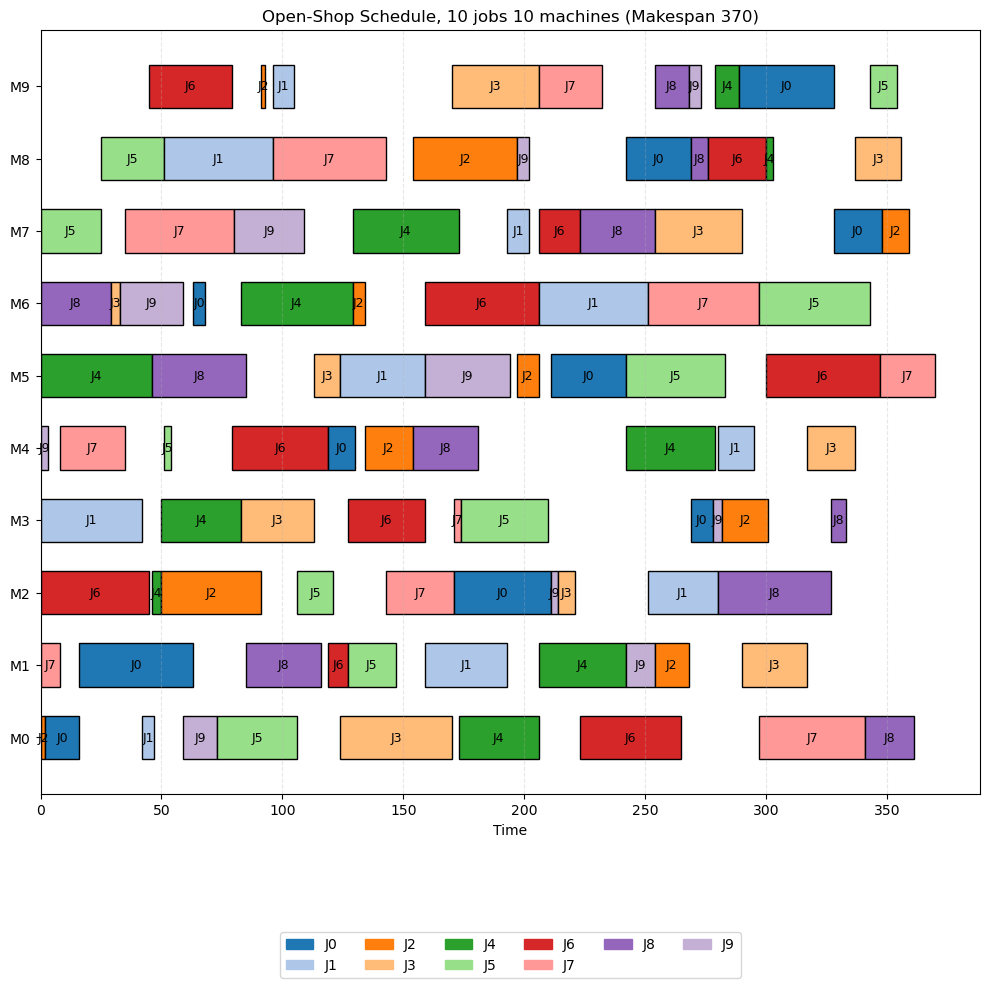

In [120]:
plot_schedule_gantt(best_3['schedule'], makespan=None, title="Open-Shop Schedule, 10 jobs 10 machines (Makespan 370)")

In [52]:
print_schedule(best_3['schedule'], best_3["makespan"])


=== MACHINE SCHEDULES ===

Machine 0 schedule:
  Job 2  | Start: 0    → Finish: 2   
  Job 6  | Start: 24   → Finish: 66  
  Job 8  | Start: 100  → Finish: 120 
  Job 5  | Start: 120  → Finish: 153 
  Job 0  | Start: 176  → Finish: 190 
  Job 9  | Start: 190  → Finish: 204 
  Job 1  | Start: 211  → Finish: 216 
  Job 7  | Start: 216  → Finish: 260 
  Job 3  | Start: 280  → Finish: 326 
  Job 4  | Start: 356  → Finish: 389 

Machine 1 schedule:
  Job 9  | Start: 3    → Finish: 15  
  Job 1  | Start: 15   → Finish: 49  
  Job 4  | Start: 49   → Finish: 85  
  Job 5  | Start: 85   → Finish: 105 
  Job 7  | Start: 122  → Finish: 130 
  Job 6  | Start: 179  → Finish: 187 
  Job 3  | Start: 187  → Finish: 214 
  Job 2  | Start: 235  → Finish: 249 
  Job 0  | Start: 249  → Finish: 296 
  Job 8  | Start: 296  → Finish: 327 

Machine 2 schedule:
  Job 9  | Start: 0    → Finish: 3   
  Job 0  | Start: 39   → Finish: 79  
  Job 7  | Start: 94   → Finish: 122 
  Job 1  | Start: 144  → Finish: 173

## Test 4: 15 jobs 10 Machines

In [53]:
test_4 = test_set.iloc[3].to_dict()
test_4

{'num_jobs': 15,
 'num_machines': 10,
 'prompt_jobs_first': 'Optimize schedule for 15 Jobs across 10 Machines to minimize makespan. Each job involves a series of Operations needing specific machines and times. Operations are processed in order, without interruption, on a single Machine at a time.\n\nProblem: \n\n Job 0 consists of the following Operations:\n  Operation 0 on Machine 1 duration 13 mins.\n  Operation 1 on Machine 8 duration 86 mins.\n  Operation 2 on Machine 3 duration 10 mins.\n  Operation 3 on Machine 9 duration 73 mins.\n  Operation 4 on Machine 5 duration 85 mins.\n  Operation 5 on Machine 4 duration 46 mins.\n  Operation 6 on Machine 7 duration 17 mins.\n  Operation 7 on Machine 0 duration 10 mins.\n  Operation 8 on Machine 6 duration 118 mins.\n  Operation 9 on Machine 2 duration 42 mins.\n\n\n Job 1 consists of the following Operations:\n  Operation 0 on Machine 4 duration 67 mins.\n  Operation 1 on Machine 9 duration 112 mins.\n  Operation 2 on Machine 5 duration 

In [54]:
test_4 = str(test_set.iloc[3]["prompt_jobs_first"])
matrix_4 = create_operations_matrix(test_4)
durations_4, jobs_4, machines_4 = build_problem(matrix_4)

In [55]:
import time

start = time.perf_counter()

rand4_1000, rand4_1000df = initial_population(durations_4, jobs_4, machines_4, population_size=1, runs=1000)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")
rand4_1000df

Runtime: 2.938392 seconds


,Run,Makespan
0,998,1374


In [56]:
import time

start = time.perf_counter()

rand4_3000, rand4_3000df = initial_population(durations_4, jobs_4, machines_4, population_size=1, runs=3000)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")
rand4_3000df

Runtime: 8.863825 seconds


,Run,Makespan
0,2022,1371


In [165]:
import time

start = time.perf_counter()

pop0_4, pop0_df_4 = initial_population(durations_4, jobs_4, machines_4, population_size=40, runs=100)

popN_4, best_4, master_df_4 = run_ga(
    initial_population=pop0_4,
    durations=durations_4,
    simulate_open_shop=simulate_open_shop,
    woc_matching_operations_fn=WoC_matching_operations,
    build_woc_child_by_sequences_fn=build_woc_child_by_sequences,
    build_woc_child_by_adjacency_fn=build_woc_child_by_adjacency,
    max_generations=100,
    patience=20,    
    verbose=True
)

master_df_4 = master_df_4.sort_values("Makespan").reset_index(drop=True)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")

Gen 0 best makespan: 1396
Gen 1 best makespan: 1396
Gen 2 best makespan: 1393
Gen 3 best makespan: 1393
Gen 4 best makespan: 1393
Gen 5 best makespan: 1393
Gen 6 best makespan: 1393
Gen 7 best makespan: 1393
Gen 8 best makespan: 1393
Gen 9 best makespan: 1393
Gen 10 best makespan: 1392
Gen 11 best makespan: 1392
Gen 12 best makespan: 1392
Gen 13 best makespan: 1371
Gen 14 best makespan: 1371
Gen 15 best makespan: 1371
Gen 16 best makespan: 1371
Gen 17 best makespan: 1371
Gen 18 best makespan: 1371
Gen 19 best makespan: 1371
Gen 20 best makespan: 1371
Gen 21 best makespan: 1364
Gen 22 best makespan: 1364
Gen 23 best makespan: 1364
Gen 24 best makespan: 1364
Gen 25 best makespan: 1364
Gen 26 best makespan: 1364
Gen 27 best makespan: 1357
Gen 28 best makespan: 1357
Gen 29 best makespan: 1357
Gen 30 best makespan: 1357
Gen 31 best makespan: 1357
Gen 32 best makespan: 1357
Gen 33 best makespan: 1357
Gen 34 best makespan: 1357
Gen 35 best makespan: 1357
Gen 36 best makespan: 1350
Gen 37 best

In [58]:
print_schedule(best_4['schedule'], best_4["makespan"])


=== MACHINE SCHEDULES ===

Machine 0 schedule:
  Job 8  | Start: 0    → Finish: 102 
  Job 0  | Start: 132  → Finish: 142 
  Job 3  | Start: 142  → Finish: 152 
  Job 1  | Start: 171  → Finish: 220 
  Job 11 | Start: 220  → Finish: 256 
  Job 12 | Start: 256  → Finish: 358 
  Job 2  | Start: 441  → Finish: 549 
  Job 13 | Start: 549  → Finish: 652 
  Job 6  | Start: 652  → Finish: 654 
  Job 14 | Start: 654  → Finish: 735 
  Job 5  | Start: 735  → Finish: 852 
  Job 4  | Start: 872  → Finish: 965 
  Job 9  | Start: 965  → Finish: 1073
  Job 10 | Start: 1073 → Finish: 1085
  Job 7  | Start: 1137 → Finish: 1166

Machine 1 schedule:
  Job 12 | Start: 14   → Finish: 71  
  Job 1  | Start: 71   → Finish: 171 
  Job 14 | Start: 171  → Finish: 250 
  Job 6  | Start: 250  → Finish: 282 
  Job 4  | Start: 282  → Finish: 406 
  Job 9  | Start: 429  → Finish: 499 
  Job 5  | Start: 499  → Finish: 558 
  Job 13 | Start: 654  → Finish: 749 
  Job 2  | Start: 790  → Finish: 904 
  Job 10 | Start: 9

## Test 5: 15 jobs 15 Machines

In [59]:
test_5 = test_set.iloc[4].to_dict()
test_5

{'num_jobs': 15,
 'num_machines': 15,
 'prompt_jobs_first': 'Optimize schedule for 15 Jobs across 15 Machines to minimize makespan. Each job involves a series of Operations needing specific machines and times. Operations are processed in order, without interruption, on a single Machine at a time.\n\nProblem: \n\n Job 0 consists of the following Operations:\n  Operation 0 on Machine 3 duration 331 mins.\n  Operation 1 on Machine 12 duration 85 mins.\n  Operation 2 on Machine 1 duration 207 mins.\n  Operation 3 on Machine 0 duration 314 mins.\n  Operation 4 on Machine 11 duration 380 mins.\n  Operation 5 on Machine 4 duration 110 mins.\n  Operation 6 on Machine 14 duration 156 mins.\n  Operation 7 on Machine 10 duration 237 mins.\n  Operation 8 on Machine 13 duration 188 mins.\n  Operation 9 on Machine 6 duration 313 mins.\n  Operation 10 on Machine 9 duration 347 mins.\n  Operation 11 on Machine 7 duration 140 mins.\n  Operation 12 on Machine 8 duration 102 mins.\n  Operation 13 on Mach

In [60]:
test_5 = str(test_set.iloc[4]["prompt_jobs_first"])
matrix_5 = create_operations_matrix(test_5)
durations_5, jobs_5, machines_5 = build_problem(matrix_5)

In [61]:
import time

start = time.perf_counter()

rand5_1000, rand5_1000df = initial_population(durations_5, jobs_5, machines_5, population_size=1, runs=1000)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")
rand5_1000df

Runtime: 6.751511 seconds


,Run,Makespan
0,815,4984


In [62]:
import time

start = time.perf_counter()

rand5_1500, rand5_1500df = initial_population(durations_5, jobs_5, machines_5, population_size=1, runs=1500)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")
rand5_1500df

Runtime: 9.955653 seconds


,Run,Makespan
0,49,4984


In [63]:
import time

start = time.perf_counter()

pop0_5, pop0_df_5 = initial_population(durations_5, jobs_5, machines_5, population_size=40, runs=100)

popN_5, best_5, master_df_5 = run_ga(
    initial_population=pop0_5,
    durations=durations_5,
    simulate_open_shop=simulate_open_shop,
    woc_matching_operations_fn=WoC_matching_operations,
    build_woc_child_by_sequences_fn=build_woc_child_by_sequences,
    build_woc_child_by_adjacency_fn=build_woc_child_by_adjacency,
    max_generations=100,
    patience=20,    
    verbose=True
)

master_df_5 = master_df_5.sort_values("Makespan").reset_index(drop=True)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")

Gen 0 best makespan: 5149
Gen 1 best makespan: 5149
Gen 2 best makespan: 5149
Gen 3 best makespan: 5149
Gen 4 best makespan: 5016
Gen 5 best makespan: 5016
Gen 6 best makespan: 5016
Gen 7 best makespan: 5016
Gen 8 best makespan: 5016
Gen 9 best makespan: 5016
Gen 10 best makespan: 4997
Gen 11 best makespan: 4997
Gen 12 best makespan: 4997
Gen 13 best makespan: 4997
Gen 14 best makespan: 4997
Gen 15 best makespan: 4997
Gen 16 best makespan: 4997
Gen 17 best makespan: 4997
Gen 18 best makespan: 4997
Gen 19 best makespan: 4997
Gen 20 best makespan: 4997
Gen 21 best makespan: 4997
Gen 22 best makespan: 4997
Gen 23 best makespan: 4997
Gen 24 best makespan: 4997
Gen 25 best makespan: 4997
Gen 26 best makespan: 4997
Gen 27 best makespan: 4997
Gen 28 best makespan: 4997
Gen 29 best makespan: 4997
Gen 30 best makespan: 4997
Early stopping at Gen 30: no improvement for 20 generations.
Runtime: 8.424769 seconds


In [64]:
print_schedule(best_5['schedule'], best_5["makespan"])


=== MACHINE SCHEDULES ===

Machine 0 schedule:
  Job 6  | Start: 0    → Finish: 94  
  Job 14 | Start: 294  → Finish: 484 
  Job 10 | Start: 535  → Finish: 742 
  Job 2  | Start: 742  → Finish: 974 
  Job 8  | Start: 974  → Finish: 1314
  Job 0  | Start: 1469 → Finish: 1783
  Job 5  | Start: 2123 → Finish: 2373
  Job 13 | Start: 2373 → Finish: 2679
  Job 11 | Start: 3028 → Finish: 3073
  Job 12 | Start: 3073 → Finish: 3421
  Job 7  | Start: 3421 → Finish: 3672
  Job 3  | Start: 3679 → Finish: 4044
  Job 4  | Start: 4222 → Finish: 4452
  Job 1  | Start: 4452 → Finish: 4518
  Job 9  | Start: 4540 → Finish: 4600

Machine 1 schedule:
  Job 7  | Start: 0    → Finish: 209 
  Job 14 | Start: 484  → Finish: 531 
  Job 1  | Start: 843  → Finish: 900 
  Job 6  | Start: 1290 → Finish: 1417
  Job 12 | Start: 1454 → Finish: 1481
  Job 5  | Start: 1940 → Finish: 2094
  Job 0  | Start: 2094 → Finish: 2301
  Job 2  | Start: 2573 → Finish: 2674
  Job 11 | Start: 2674 → Finish: 3028
  Job 4  | Start: 3

## Test 6: 20 jobs 20 Machines

In [65]:
test_6 = test_set.iloc[5].to_dict()
test_6

{'num_jobs': 20,
 'num_machines': 20,
 'prompt_jobs_first': 'Optimize schedule for 20 Jobs across 20 Machines to minimize makespan. Each job involves a series of Operations needing specific machines and times. Operations are processed in order, without interruption, on a single Machine at a time.\n\nProblem: \n\n Job 0 consists of the following Operations:\n  Operation 0 on Machine 0 duration 120 mins.\n  Operation 1 on Machine 11 duration 114 mins.\n  Operation 2 on Machine 7 duration 14 mins.\n  Operation 3 on Machine 18 duration 199 mins.\n  Operation 4 on Machine 9 duration 132 mins.\n  Operation 5 on Machine 2 duration 114 mins.\n  Operation 6 on Machine 3 duration 109 mins.\n  Operation 7 on Machine 17 duration 27 mins.\n  Operation 8 on Machine 12 duration 245 mins.\n  Operation 9 on Machine 16 duration 133 mins.\n  Operation 10 on Machine 4 duration 48 mins.\n  Operation 11 on Machine 15 duration 51 mins.\n  Operation 12 on Machine 8 duration 3 mins.\n  Operation 13 on Machine 

In [66]:
test_6 = str(test_set.iloc[5]["prompt_jobs_first"])
matrix_6 = create_operations_matrix(test_6)
durations_6, jobs_6, machines_6 = build_problem(matrix_6)

In [67]:
import time

start = time.perf_counter()

rand6_1000, rand6_1000df = initial_population(durations_6, jobs_6, machines_6, population_size=1, runs=1000)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")
rand6_1000df

Runtime: 18.366478 seconds


,Run,Makespan
0,104,4688


In [68]:
import time

start = time.perf_counter()

rand6_2000, rand6_2000df = initial_population(durations_6, jobs_6, machines_6, population_size=1, runs=2000)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")
rand6_2000df

Runtime: 36.471957 seconds


,Run,Makespan
0,1825,4839


In [156]:
import time

start = time.perf_counter()

pop0_6, pop0_df_6 = initial_population(durations_6, jobs_6, machines_6, population_size=80, runs=200)

popN_6, best_6, master_df_6 = run_ga(
    initial_population=pop0_6,
    durations=durations_6,
    simulate_open_shop=simulate_open_shop,
    woc_matching_operations_fn=WoC_matching_operations,
    build_woc_child_by_sequences_fn=build_woc_child_by_sequences,
    build_woc_child_by_adjacency_fn=build_woc_child_by_adjacency,
    max_generations=100,
    patience=40,    
    verbose=True
)

master_df_6 = master_df_6.sort_values("Makespan").reset_index(drop=True)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")

Gen 0 best makespan: 4944
Gen 1 best makespan: 4944
Gen 2 best makespan: 4943
Gen 3 best makespan: 4943
Gen 4 best makespan: 4846
Gen 5 best makespan: 4846
Gen 6 best makespan: 4846
Gen 7 best makespan: 4818
Gen 8 best makespan: 4818
Gen 9 best makespan: 4818
Gen 10 best makespan: 4818
Gen 11 best makespan: 4818
Gen 12 best makespan: 4793
Gen 13 best makespan: 4793
Gen 14 best makespan: 4793
Gen 15 best makespan: 4793
Gen 16 best makespan: 4793
Gen 17 best makespan: 4793
Gen 18 best makespan: 4793
Gen 19 best makespan: 4793
Gen 20 best makespan: 4793
Gen 21 best makespan: 4793
Gen 22 best makespan: 4793
Gen 23 best makespan: 4793
Gen 24 best makespan: 4793
Gen 25 best makespan: 4793
Gen 26 best makespan: 4793
Gen 27 best makespan: 4793
Gen 28 best makespan: 4793
Gen 29 best makespan: 4793
Gen 30 best makespan: 4793
Gen 31 best makespan: 4793
Gen 32 best makespan: 4793
Gen 33 best makespan: 4793
Gen 34 best makespan: 4793
Gen 35 best makespan: 4793
Gen 36 best makespan: 4793
Gen 37 best

In [70]:
print_schedule(best_6['schedule'], best_6["makespan"])


=== MACHINE SCHEDULES ===

Machine 0 schedule:
  Job 16 | Start: 261  → Finish: 325 
  Job 18 | Start: 325  → Finish: 570 
  Job 13 | Start: 570  → Finish: 714 
  Job 3  | Start: 714  → Finish: 863 
  Job 6  | Start: 1028 → Finish: 1073
  Job 5  | Start: 1207 → Finish: 1331
  Job 0  | Start: 1343 → Finish: 1463
  Job 1  | Start: 1568 → Finish: 1631
  Job 15 | Start: 1631 → Finish: 1757
  Job 10 | Start: 1877 → Finish: 1913
  Job 8  | Start: 1913 → Finish: 1993
  Job 11 | Start: 2003 → Finish: 2187
  Job 7  | Start: 2187 → Finish: 2460
  Job 14 | Start: 2472 → Finish: 2690
  Job 9  | Start: 2735 → Finish: 2874
  Job 4  | Start: 2874 → Finish: 2904
  Job 12 | Start: 2956 → Finish: 3157
  Job 17 | Start: 3356 → Finish: 3543
  Job 2  | Start: 3716 → Finish: 3970
  Job 19 | Start: 4497 → Finish: 4656

Machine 1 schedule:
  Job 13 | Start: 234  → Finish: 348 
  Job 12 | Start: 393  → Finish: 466 
  Job 18 | Start: 570  → Finish: 842 
  Job 5  | Start: 842  → Finish: 1017
  Job 19 | Start: 2

## Test 7: 30 jobs 30 Machines

In [71]:
test_7 = test_set.iloc[6].to_dict()
test_7

{'num_jobs': 30,
 'num_machines': 30,
 'prompt_jobs_first': 'J0:\nM1:94 M16:149 M22:51 M25:8 M14:159 M9:88 M3:153 M17:25 M6:104 M18:34 M5:144 M15:129 M26:17 M12:53 M4:128 M8:149 M13:142 M27:74 M0:45 M19:123 M28:30 M21:87 M11:23 M10:58 M20:120 M7:37 M2:94 M29:94 M24:73 M23:155 \nJ1:\nM6:79 M16:18 M26:70 M5:100 M17:80 M23:26 M10:53 M1:136 M25:99 M13:103 M14:6 M15:17 M22:47 M3:110 M0:69 M12:32 M4:29 M2:98 M24:66 M8:42 M20:151 M9:119 M11:158 M28:37 M7:73 M18:24 M29:10 M27:150 M21:142 M19:52 \nJ2:\nM20:164 M13:76 M6:153 M16:75 M22:20 M26:113 M7:73 M12:102 M24:32 M17:130 M9:134 M23:82 M25:133 M0:76 M21:16 M10:122 M29:80 M18:93 M15:105 M27:68 M19:147 M3:113 M2:123 M1:95 M28:49 M5:46 M8:156 M4:140 M11:38 M14:8 \nJ3:\nM22:74 M15:47 M23:150 M14:8 M10:33 M18:151 M1:108 M13:6 M4:111 M11:101 M21:151 M27:82 M6:133 M24:74 M8:83 M20:33 M29:25 M25:111 M7:137 M2:60 M0:43 M26:133 M3:79 M5:134 M19:53 M16:80 M28:79 M12:71 M17:11 M9:52 \nJ4:\nM14:137 M18:104 M12:71 M19:119 M20:20 M25:122 M16:23 M23:67 M7:11

In [72]:
test_7 = str(test_set.iloc[6]["prompt_jobs_first"])
matrix_7 = create_operations_matrix_2(test_7)
durations_7, jobs_7, machines_7 = build_problem(matrix_7)

In [73]:
import time

start = time.perf_counter()


rand7_1000, rand7_1000df = initial_population(durations_7, jobs_7, machines_7, population_size=1, runs=1000)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")
rand7_1000df

Runtime: 80.358510 seconds


,Run,Makespan
0,804,4346


In [74]:
import time

start = time.perf_counter()


rand7_1500, rand7_1500df = initial_population(durations_7, jobs_7, machines_7, population_size=1, runs=1500)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")
rand7_1500df

Runtime: 121.894624 seconds


,Run,Makespan
0,90,4309


In [75]:
import time

start = time.perf_counter()


rand7_2000, rand7_2000df = initial_population(durations_7, jobs_7, machines_7, population_size=1, runs=2000)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")
rand7_2000df

Runtime: 163.003140 seconds


,Run,Makespan
0,483,4267


In [76]:
import time

start = time.perf_counter()

pop0_7, pop0_df_7 = initial_population(durations_7, jobs_7, machines_7, population_size=40, runs=100)

popN_7, best_7, master_df_7 = run_ga(
    initial_population=pop0_7,
    durations=durations_7,
    simulate_open_shop=simulate_open_shop,
    woc_matching_operations_fn=WoC_matching_operations,
    build_woc_child_by_sequences_fn=build_woc_child_by_sequences,
    build_woc_child_by_adjacency_fn=build_woc_child_by_adjacency,
    max_generations=100,
    patience=20,    
    verbose=True
)

master_df_7 = master_df_7.sort_values("Makespan").reset_index(drop=False)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")

Gen 0 best makespan: 4368
Gen 1 best makespan: 4368
Gen 2 best makespan: 4298
Gen 3 best makespan: 4298
Gen 4 best makespan: 4298
Gen 5 best makespan: 4298
Gen 6 best makespan: 4298
Gen 7 best makespan: 4298
Gen 8 best makespan: 4298
Gen 9 best makespan: 4298
Gen 10 best makespan: 4298
Gen 11 best makespan: 4298
Gen 12 best makespan: 4298
Gen 13 best makespan: 4298
Gen 14 best makespan: 4298
Gen 15 best makespan: 4282
Gen 16 best makespan: 4282
Gen 17 best makespan: 4282
Gen 18 best makespan: 4282
Gen 19 best makespan: 4282
Gen 20 best makespan: 4282
Gen 21 best makespan: 4282
Gen 22 best makespan: 4282
Gen 23 best makespan: 4282
Gen 24 best makespan: 4282
Gen 25 best makespan: 4282
Gen 26 best makespan: 4282
Gen 27 best makespan: 4282
Gen 28 best makespan: 4282
Gen 29 best makespan: 4282
Gen 30 best makespan: 4282
Gen 31 best makespan: 4282
Gen 32 best makespan: 4282
Gen 33 best makespan: 4282
Gen 34 best makespan: 4282
Gen 35 best makespan: 4282
Early stopping at Gen 35: no improveme

In [77]:
print_schedule(best_7['schedule'], best_7["makespan"])


=== MACHINE SCHEDULES ===

Machine 0 schedule:
  Job 6  | Start: 0    → Finish: 134 
  Job 28 | Start: 134  → Finish: 230 
  Job 3  | Start: 230  → Finish: 273 
  Job 0  | Start: 273  → Finish: 318 
  Job 17 | Start: 318  → Finish: 403 
  Job 18 | Start: 505  → Finish: 587 
  Job 4  | Start: 841  → Finish: 948 
  Job 5  | Start: 948  → Finish: 1006
  Job 27 | Start: 1035 → Finish: 1173
  Job 21 | Start: 1321 → Finish: 1386
  Job 2  | Start: 1386 → Finish: 1462
  Job 14 | Start: 1469 → Finish: 1508
  Job 10 | Start: 1508 → Finish: 1555
  Job 22 | Start: 1592 → Finish: 1719
  Job 20 | Start: 1719 → Finish: 1879
  Job 8  | Start: 1980 → Finish: 2017
  Job 13 | Start: 2017 → Finish: 2126
  Job 23 | Start: 2316 → Finish: 2410
  Job 16 | Start: 2410 → Finish: 2527
  Job 12 | Start: 2594 → Finish: 2609
  Job 7  | Start: 2609 → Finish: 2686
  Job 29 | Start: 2745 → Finish: 2876
  Job 1  | Start: 2909 → Finish: 2978
  Job 9  | Start: 2978 → Finish: 3078
  Job 25 | Start: 3078 → Finish: 3196
  

## Test 8: 30 jobs 15 Machines

In [122]:
test_8 = str(test_set.iloc[7]["prompt_jobs_first"])
matrix_8 = create_operations_matrix_2(test_8)
durations_8, jobs_8, machines_8 = build_problem(matrix_8)

In [79]:
import time

start = time.perf_counter()

rand8_1000, rand8_1000df = initial_population(durations_8, jobs_8, machines_8, population_size=1, runs=1000)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")
rand8_1000df

Runtime: 20.093595 seconds


,Run,Makespan
0,521,4877


In [80]:
import time

start = time.perf_counter()

rand8_1500, rand8_1500df = initial_population(durations_8, jobs_8, machines_8, population_size=1, runs=1500)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")
rand8_1500df

Runtime: 29.758855 seconds


,Run,Makespan
0,771,4774


In [132]:
import time

start = time.perf_counter()

rand8_2000, rand8_2000df = initial_population(durations_8, jobs_8, machines_8, population_size=1, runs=10000)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")
rand8_2000df

Runtime: 208.016239 seconds


,Run,Makespan
0,2816,4825


In [131]:
import time

start = time.perf_counter()
pop0_8, pop0_df_8 = initial_population(durations_8, jobs_8, machines_8, population_size=80, runs=200)

popN_8, best_8, master_df_8 = run_ga(
    initial_population=pop0_8,
    durations=durations_8,
    simulate_open_shop=simulate_open_shop,
    woc_matching_operations_fn=WoC_matching_operations,
    build_woc_child_by_sequences_fn=build_woc_child_by_sequences,
    build_woc_child_by_adjacency_fn=build_woc_child_by_adjacency,
    max_generations=200,
    patience=30,    
    verbose=True
)

master_df_8 = master_df_8.sort_values("Makespan").reset_index(drop=False)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")

Gen 0 best makespan: 4940
Gen 1 best makespan: 4940
Gen 2 best makespan: 4905
Gen 3 best makespan: 4905
Gen 4 best makespan: 4905
Gen 5 best makespan: 4905
Gen 6 best makespan: 4905
Gen 7 best makespan: 4905
Gen 8 best makespan: 4905
Gen 9 best makespan: 4900
Gen 10 best makespan: 4900
Gen 11 best makespan: 4900
Gen 12 best makespan: 4900
Gen 13 best makespan: 4900
Gen 14 best makespan: 4900
Gen 15 best makespan: 4900
Gen 16 best makespan: 4900
Gen 17 best makespan: 4900
Gen 18 best makespan: 4900
Gen 19 best makespan: 4900
Gen 20 best makespan: 4900
Gen 21 best makespan: 4878
Gen 22 best makespan: 4878
Gen 23 best makespan: 4878
Gen 24 best makespan: 4878
Gen 25 best makespan: 4878
Gen 26 best makespan: 4878
Gen 27 best makespan: 4878
Gen 28 best makespan: 4878
Gen 29 best makespan: 4878
Gen 30 best makespan: 4878
Gen 31 best makespan: 4878
Gen 32 best makespan: 4878
Gen 33 best makespan: 4878
Gen 34 best makespan: 4878
Gen 35 best makespan: 4878
Gen 36 best makespan: 4878
Gen 37 best

In [83]:
print_schedule(best_8['schedule'], best_8["makespan"])


=== MACHINE SCHEDULES ===

Machine 0 schedule:
  Job 26 | Start: 0    → Finish: 131 
  Job 0  | Start: 144  → Finish: 229 
  Job 2  | Start: 229  → Finish: 380 
  Job 8  | Start: 380  → Finish: 530 
  Job 23 | Start: 530  → Finish: 603 
  Job 9  | Start: 691  → Finish: 848 
  Job 17 | Start: 848  → Finish: 1044
  Job 4  | Start: 1118 → Finish: 1201
  Job 18 | Start: 1278 → Finish: 1349
  Job 1  | Start: 1432 → Finish: 1491
  Job 19 | Start: 1491 → Finish: 1662
  Job 7  | Start: 1670 → Finish: 1717
  Job 24 | Start: 1737 → Finish: 1861
  Job 15 | Start: 1972 → Finish: 2042
  Job 21 | Start: 2042 → Finish: 2102
  Job 10 | Start: 2102 → Finish: 2205
  Job 28 | Start: 2205 → Finish: 2338
  Job 22 | Start: 2500 → Finish: 2669
  Job 25 | Start: 2669 → Finish: 2754
  Job 6  | Start: 2754 → Finish: 2960
  Job 13 | Start: 2960 → Finish: 3097
  Job 5  | Start: 3294 → Finish: 3495
  Job 27 | Start: 3495 → Finish: 3505
  Job 29 | Start: 3505 → Finish: 3620
  Job 14 | Start: 3620 → Finish: 3779
  

## Test 9: 40 jobs 40 Machines

In [84]:
test_9 = test_set.iloc[8].to_dict()
test_9

{'num_jobs': 40,
 'num_machines': 40,
 'prompt_jobs_first': 'J0:\nM36:16 M4:12 M7:25 M6:7 M38:7 M21:6 M28:7 M19:17 M0:11 M39:20 M35:22 M30:6 M10:12 M16:6 M34:14 M32:6 M2:14 M24:12 M5:15 M37:16 M12:20 M31:12 M29:24 M22:6 M8:25 M1:15 M15:23 M20:13 M25:16 M3:11 M23:20 M27:16 M9:14 M26:23 M17:19 M14:17 M13:7 M11:24 M18:7 M33:11 \nJ1:\nM24:23 M27:8 M34:17 M26:23 M15:12 M19:11 M31:15 M20:5 M14:14 M9:5 M28:21 M1:24 M30:16 M13:13 M5:23 M6:20 M0:9 M23:16 M32:20 M8:22 M25:17 M22:15 M37:10 M16:13 M17:5 M3:14 M21:19 M35:5 M12:13 M11:23 M29:5 M38:8 M2:6 M7:7 M36:19 M39:19 M10:20 M33:23 M18:19 M4:17 \nJ2:\nM9:19 M20:12 M37:20 M34:24 M6:17 M24:22 M38:6 M30:11 M7:18 M14:25 M39:20 M36:5 M31:8 M21:16 M1:13 M5:8 M3:12 M23:18 M27:15 M15:18 M29:10 M25:24 M12:18 M4:24 M16:20 M0:9 M13:10 M11:20 M18:15 M2:22 M28:15 M17:19 M10:9 M32:8 M8:25 M19:25 M26:18 M35:22 M33:15 M22:13 \nJ3:\nM6:18 M27:19 M35:5 M25:22 M28:18 M2:17 M12:11 M0:7 M31:21 M23:7 M18:25 M36:22 M1:25 M24:16 M4:18 M9:19 M10:20 M33:16 M20:25 M32:16

In [85]:
test_9 = str(test_set.iloc[8]["prompt_jobs_first"])
matrix_9 = create_operations_matrix_2(test_9)
durations_9, jobs_9, machines_9 = build_problem(matrix_9)

In [86]:
import time

start = time.perf_counter()

rand9_1000, rand9_1000_df = initial_population(durations_9, jobs_9, machines_9, population_size=1, runs=1000)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")
rand9_1000_df

Runtime: 221.074227 seconds


,Run,Makespan
0,415,1032


In [87]:
import time

start = time.perf_counter()
pop0_9, pop0_df_9 = initial_population(durations_9, jobs_9, machines_9, population_size=40, runs=100)

popN_9, best_9, master_df_9 = run_ga(
    initial_population=pop0_9,
    durations=durations_9,
    simulate_open_shop=simulate_open_shop,
    woc_matching_operations_fn=WoC_matching_operations,
    build_woc_child_by_sequences_fn=build_woc_child_by_sequences,
    build_woc_child_by_adjacency_fn=build_woc_child_by_adjacency,
    max_generations=100,
    patience=20,    
    verbose=True
)

master_df_9 = master_df_9.sort_values("Makespan").reset_index(drop=False)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")

Gen 0 best makespan: 1044
Gen 1 best makespan: 1044
Gen 2 best makespan: 1044
Gen 3 best makespan: 1043
Gen 4 best makespan: 1040
Gen 5 best makespan: 1036
Gen 6 best makespan: 1036
Gen 7 best makespan: 1036
Gen 8 best makespan: 1036
Gen 9 best makespan: 1034
Gen 10 best makespan: 1034
Gen 11 best makespan: 1034
Gen 12 best makespan: 1034
Gen 13 best makespan: 1034
Gen 14 best makespan: 1034
Gen 15 best makespan: 1033
Gen 16 best makespan: 1033
Gen 17 best makespan: 1033
Gen 18 best makespan: 1031
Gen 19 best makespan: 1031
Gen 20 best makespan: 1031
Gen 21 best makespan: 1031
Gen 22 best makespan: 1031
Gen 23 best makespan: 1031
Gen 24 best makespan: 1031
Gen 25 best makespan: 1031
Gen 26 best makespan: 1031
Gen 27 best makespan: 1031
Gen 28 best makespan: 1031
Gen 29 best makespan: 1031
Gen 30 best makespan: 1031
Gen 31 best makespan: 1021
Gen 32 best makespan: 1021
Gen 33 best makespan: 1021
Gen 34 best makespan: 1021
Gen 35 best makespan: 1021
Gen 36 best makespan: 1021
Gen 37 best

In [88]:
print_schedule(best_9['schedule'], best_9["makespan"])


=== MACHINE SCHEDULES ===

Machine 0 schedule:
  Job 24 | Start: 9    → Finish: 16  
  Job 25 | Start: 20   → Finish: 36  
  Job 14 | Start: 36   → Finish: 55  
  Job 31 | Start: 199  → Finish: 222 
  Job 12 | Start: 231  → Finish: 250 
  Job 33 | Start: 251  → Finish: 270 
  Job 17 | Start: 301  → Finish: 306 
  Job 4  | Start: 354  → Finish: 371 
  Job 26 | Start: 371  → Finish: 396 
  Job 20 | Start: 396  → Finish: 417 
  Job 18 | Start: 420  → Finish: 432 
  Job 8  | Start: 451  → Finish: 465 
  Job 5  | Start: 471  → Finish: 479 
  Job 36 | Start: 479  → Finish: 491 
  Job 2  | Start: 491  → Finish: 500 
  Job 10 | Start: 531  → Finish: 536 
  Job 32 | Start: 544  → Finish: 560 
  Job 15 | Start: 565  → Finish: 582 
  Job 19 | Start: 589  → Finish: 596 
  Job 13 | Start: 596  → Finish: 603 
  Job 27 | Start: 610  → Finish: 624 
  Job 16 | Start: 624  → Finish: 648 
  Job 23 | Start: 648  → Finish: 670 
  Job 7  | Start: 728  → Finish: 738 
  Job 35 | Start: 742  → Finish: 748 
  

## Test 10: 40 jobs 20 Machines

In [89]:
test_10 = test_set.iloc[9].to_dict()
test_10

{'num_jobs': 40,
 'num_machines': 20,
 'prompt_jobs_first': 'J0:\nM3:138 M17:150 M4:151 M15:226 M10:40 M13:223 M19:266 M8:189 M16:89 M18:211 M1:67 M0:188 M12:76 M7:18 M11:13 M14:152 M2:132 M5:68 M9:165 M6:56 \nJ1:\nM2:101 M11:93 M19:256 M16:192 M18:88 M0:237 M5:15 M9:56 M13:232 M12:153 M3:171 M4:79 M15:252 M6:212 M17:80 M10:89 M7:51 M8:228 M14:196 M1:133 \nJ2:\nM13:261 M19:90 M14:255 M16:106 M7:97 M3:31 M10:256 M0:265 M9:176 M6:261 M1:63 M17:214 M5:10 M4:130 M18:237 M8:110 M15:184 M11:94 M2:12 M12:48 \nJ3:\nM0:205 M9:183 M7:85 M14:103 M17:87 M3:90 M11:181 M1:122 M5:198 M16:40 M12:242 M4:99 M19:150 M8:45 M2:205 M10:260 M18:91 M15:11 M6:134 M13:16 \nJ4:\nM19:88 M10:240 M0:186 M13:142 M11:174 M4:99 M2:161 M14:113 M5:266 M6:238 M16:21 M8:97 M17:251 M3:132 M15:30 M18:110 M12:186 M9:136 M7:179 M1:98 \nJ5:\nM10:238 M11:95 M12:220 M7:174 M6:129 M1:159 M0:181 M16:221 M13:140 M17:248 M9:69 M4:8 M14:18 M3:43 M5:162 M8:14 M18:7 M15:165 M19:10 M2:131 \nJ6:\nM5:146 M7:254 M0:230 M15:186 M16:207 M3:2

In [90]:
test_10 = str(test_set.iloc[9]["prompt_jobs_first"])
matrix_10 = create_operations_matrix_2(test_10)
durations_10, jobs_10, machines_10 = build_problem(matrix_10)

In [137]:
import time

start = time.perf_counter()

rand10_1000, rand10_1000_df = initial_population(durations_10, jobs_10, machines_10, population_size=1, runs=3000)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")
rand10_1000_df

Runtime: 217.583587 seconds


,Run,Makespan
0,356,7322


In [138]:
import time

start = time.perf_counter()

rand10_1000, rand10_1000_df = initial_population(durations_10, jobs_10, machines_10, population_size=1, runs=3000)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")
rand10_1000_df

Runtime: 209.316935 seconds


,Run,Makespan
0,2384,7203


In [139]:
import time

start = time.perf_counter()

rand10_1500, rand10_1500_df = initial_population(durations_10, jobs_10, machines_10, population_size=1, runs=3000)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")
rand10_1500_df

Runtime: 190.313572 seconds


,Run,Makespan
0,144,7357


In [136]:
import time

start = time.perf_counter()
pop0_10, pop0_df_10 = initial_population(durations_10, jobs_10, machines_10, population_size=80, runs=200)

popN_10, best_10, master_df_10 = run_ga(
    initial_population=pop0_10,
    durations=durations_10,
    simulate_open_shop=simulate_open_shop,
    woc_matching_operations_fn=WoC_matching_operations,
    build_woc_child_by_sequences_fn=build_woc_child_by_sequences,
    build_woc_child_by_adjacency_fn=build_woc_child_by_adjacency,
    max_generations=100,
    patience=30,    
    verbose=True
)

master_df_10 = master_df_10.sort_values("Makespan").reset_index(drop=False)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")

Gen 0 best makespan: 7438
Gen 1 best makespan: 7405
Gen 2 best makespan: 7405
Gen 3 best makespan: 7405
Gen 4 best makespan: 7374
Gen 5 best makespan: 7374
Gen 6 best makespan: 7374
Gen 7 best makespan: 7374
Gen 8 best makespan: 7374
Gen 9 best makespan: 7374
Gen 10 best makespan: 7374
Gen 11 best makespan: 7374
Gen 12 best makespan: 7374
Gen 13 best makespan: 7374
Gen 14 best makespan: 7374
Gen 15 best makespan: 7374
Gen 16 best makespan: 7374
Gen 17 best makespan: 7374
Gen 18 best makespan: 7374
Gen 19 best makespan: 7374
Gen 20 best makespan: 7374
Gen 21 best makespan: 7374
Gen 22 best makespan: 7354
Gen 23 best makespan: 7354
Gen 24 best makespan: 7318
Gen 25 best makespan: 7318
Gen 26 best makespan: 7318
Gen 27 best makespan: 7235
Gen 28 best makespan: 7235
Gen 29 best makespan: 7235
Gen 30 best makespan: 7235
Gen 31 best makespan: 7235
Gen 32 best makespan: 7235
Gen 33 best makespan: 7235
Gen 34 best makespan: 7235
Gen 35 best makespan: 7235
Gen 36 best makespan: 7235
Gen 37 best

In [133]:
import time

start = time.perf_counter()
pop0_10, pop0_df_10 = initial_population(durations_10, jobs_10, machines_10, population_size=80, runs=200)

popN_10, best_10, master_df_10 = run_ga(
    initial_population=pop0_10,
    durations=durations_10,
    simulate_open_shop=simulate_open_shop,
    woc_matching_operations_fn=WoC_matching_operations,
    build_woc_child_by_sequences_fn=build_woc_child_by_sequences,
    build_woc_child_by_adjacency_fn=build_woc_child_by_adjacency,
    max_generations=100,
    patience=30,    
    verbose=True
)

master_df_10 = master_df_10.sort_values("Makespan").reset_index(drop=False)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")

Gen 0 best makespan: 7459
Gen 1 best makespan: 7272
Gen 2 best makespan: 7272
Gen 3 best makespan: 7272
Gen 4 best makespan: 7272
Gen 5 best makespan: 7272
Gen 6 best makespan: 7272
Gen 7 best makespan: 7272
Gen 8 best makespan: 7272
Gen 9 best makespan: 7272
Gen 10 best makespan: 7272
Gen 11 best makespan: 7272
Gen 12 best makespan: 7272
Gen 13 best makespan: 7272
Gen 14 best makespan: 7272
Gen 15 best makespan: 7272
Gen 16 best makespan: 7272
Gen 17 best makespan: 7272
Gen 18 best makespan: 7272
Gen 19 best makespan: 7272
Gen 20 best makespan: 7272
Gen 21 best makespan: 7272
Early stopping at Gen 21: no improvement for 20 generations.
Runtime: 112.867833 seconds


In [134]:
import time

start = time.perf_counter()
pop0_10, pop0_df_10 = initial_population(durations_10, jobs_10, machines_10, population_size=80, runs=200)

popN_101, best_101, master_df_101 = run_ga(
    initial_population=pop0_10,
    durations=durations_10,
    simulate_open_shop=simulate_open_shop,
    woc_matching_operations_fn=WoC_matching_operations,
    build_woc_child_by_sequences_fn=build_woc_child_by_sequences,
    build_woc_child_by_adjacency_fn=build_woc_child_by_adjacency,
    max_generations=100,
    patience=30,    
    verbose=True
)

master_df_10 = master_df_10.sort_values("Makespan").reset_index(drop=False)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")

Gen 0 best makespan: 7290
Gen 1 best makespan: 7290
Gen 2 best makespan: 7290
Gen 3 best makespan: 7290
Gen 4 best makespan: 7290
Gen 5 best makespan: 7290
Gen 6 best makespan: 7290
Gen 7 best makespan: 7290
Gen 8 best makespan: 7290
Gen 9 best makespan: 7290
Gen 10 best makespan: 7290
Gen 11 best makespan: 7290
Gen 12 best makespan: 7290
Gen 13 best makespan: 7290
Gen 14 best makespan: 7290
Gen 15 best makespan: 7290
Gen 16 best makespan: 7290
Gen 17 best makespan: 7290
Gen 18 best makespan: 7290
Gen 19 best makespan: 7290
Gen 20 best makespan: 7290
Early stopping at Gen 20: no improvement for 20 generations.
Runtime: 115.351856 seconds


In [135]:
import time

start = time.perf_counter()
pop0_10, pop0_df_10 = initial_population(durations_10, jobs_10, machines_10, population_size=80, runs=200)

popN_102, best_102, master_df_102 = run_ga(
    initial_population=pop0_10,
    durations=durations_10,
    simulate_open_shop=simulate_open_shop,
    woc_matching_operations_fn=WoC_matching_operations,
    build_woc_child_by_sequences_fn=build_woc_child_by_sequences,
    build_woc_child_by_adjacency_fn=build_woc_child_by_adjacency,
    max_generations=100,
    patience=30,    
    verbose=True
)

master_df_10 = master_df_10.sort_values("Makespan").reset_index(drop=False)

end = time.perf_counter()

print(f"Runtime: {end - start:.6f} seconds")

Gen 0 best makespan: 7384
Gen 1 best makespan: 7384
Gen 2 best makespan: 7384
Gen 3 best makespan: 7384
Gen 4 best makespan: 7384
Gen 5 best makespan: 7384
Gen 6 best makespan: 7384
Gen 7 best makespan: 7319
Gen 8 best makespan: 7319
Gen 9 best makespan: 7319
Gen 10 best makespan: 7319
Gen 11 best makespan: 7319
Gen 12 best makespan: 7319
Gen 13 best makespan: 7319
Gen 14 best makespan: 7319
Gen 15 best makespan: 7319
Gen 16 best makespan: 7319
Gen 17 best makespan: 7319
Gen 18 best makespan: 7319
Gen 19 best makespan: 7319
Gen 20 best makespan: 7319
Gen 21 best makespan: 7319
Gen 22 best makespan: 7319
Gen 23 best makespan: 7319
Gen 24 best makespan: 7319
Gen 25 best makespan: 7319
Gen 26 best makespan: 7284
Gen 27 best makespan: 7284
Gen 28 best makespan: 7284
Gen 29 best makespan: 7284
Gen 30 best makespan: 7284
Gen 31 best makespan: 7284
Gen 32 best makespan: 7284
Gen 33 best makespan: 7284
Gen 34 best makespan: 7284
Gen 35 best makespan: 7284
Gen 36 best makespan: 7284
Gen 37 best

ValueError: cannot insert level_0, already exists

In [94]:
print_schedule(best_10['schedule'], best_10["makespan"])


=== MACHINE SCHEDULES ===

Machine 0 schedule:
  Job 37 | Start: 0    → Finish: 196 
  Job 16 | Start: 316  → Finish: 446 
  Job 3  | Start: 446  → Finish: 651 
  Job 6  | Start: 782  → Finish: 1012
  Job 32 | Start: 1012 → Finish: 1039
  Job 14 | Start: 1039 → Finish: 1286
  Job 4  | Start: 1412 → Finish: 1598
  Job 35 | Start: 1598 → Finish: 1626
  Job 30 | Start: 1767 → Finish: 1868
  Job 1  | Start: 1896 → Finish: 2133
  Job 31 | Start: 2133 → Finish: 2399
  Job 12 | Start: 2573 → Finish: 2599
  Job 15 | Start: 2739 → Finish: 2875
  Job 17 | Start: 2926 → Finish: 3026
  Job 36 | Start: 3026 → Finish: 3163
  Job 28 | Start: 3163 → Finish: 3298
  Job 0  | Start: 3335 → Finish: 3523
  Job 29 | Start: 3523 → Finish: 3757
  Job 21 | Start: 3840 → Finish: 3896
  Job 18 | Start: 3896 → Finish: 4120
  Job 34 | Start: 4120 → Finish: 4377
  Job 33 | Start: 4377 → Finish: 4613
  Job 22 | Start: 4613 → Finish: 4744
  Job 19 | Start: 4761 → Finish: 4970
  Job 27 | Start: 4970 → Finish: 5042
  

In [95]:
master_df_10

,index,Run,Gen,Source,Makespan
0,600,617,15,woc_adj,7318
1,1240,617,31,woc_adj,7318
2,680,617,17,woc_adj,7318
3,920,617,23,woc_adj,7318
4,560,617,14,woc_adj,7318
...,...,...,...,...,...
1395,399,444,9,woc_ops,8453
1396,879,825,21,woc_adj,8481
1397,199,289,4,woc_ops,8485
1398,519,544,12,woc_seq,8531


In [96]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_schedule_gantt(schedule_by_machine, makespan=None, title="Open-Shop Schedule (Gantt)"):
    """
    Draws a Gantt chart per machine from schedule_by_machine.
    schedule_by_machine: dict[int -> list[(job, start, finish)]]
    """
    machines = sorted(schedule_by_machine.keys())
    # collect unique jobs for colors
    jobs_set = sorted({j for m in machines for (j, _, _) in schedule_by_machine[m]})
    # build a color map per job
    cmap = plt.get_cmap("tab20")
    color_for_job = {j: cmap(i % 20) for i, j in enumerate(jobs_set)}

    fig, ax = plt.subplots(figsize=(10, 0.8*len(machines) + 2))
    yticks = []
    yticklabels = []

    for idx, m in enumerate(machines):
        y = idx
        yticks.append(y)
        yticklabels.append(f"M{m}")
        for (job, start, finish) in schedule_by_machine[m]:
            ax.barh(y, width=finish-start, left=start, height=0.6,
                    edgecolor="black", color=color_for_job[job])
            ax.text(start + (finish-start)/2, y, f"J{job}",
                    va="center", ha="center", fontsize=9, color="black")

    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels)
    ax.set_xlabel("Time")
    ax.set_title(title if makespan is None else f"{title} — makespan={makespan}")
    ax.grid(True, axis="x", linestyle="--", alpha=0.3)

    # Legend
    handles = [mpatches.Patch(color=color_for_job[j], label=f"J{j}") for j in jobs_set]
    ax.legend(handles=handles, ncol=min(len(handles), 6), bbox_to_anchor=(0.5, -0.25), loc="lower center")
    plt.tight_layout()
    plt.show()


In [97]:
best_3['schedule']

{0: [(2, 0, 2),
  (6, 24, 66),
  (8, 100, 120),
  (5, 120, 153),
  (0, 176, 190),
  (9, 190, 204),
  (1, 211, 216),
  (7, 216, 260),
  (3, 280, 326),
  (4, 356, 389)],
 1: [(9, 3, 15),
  (1, 15, 49),
  (4, 49, 85),
  (5, 85, 105),
  (7, 122, 130),
  (6, 179, 187),
  (3, 187, 214),
  (2, 235, 249),
  (0, 249, 296),
  (8, 296, 327)],
 2: [(9, 0, 3),
  (0, 39, 79),
  (7, 94, 122),
  (1, 144, 173),
  (4, 190, 194),
  (2, 194, 235),
  (3, 235, 242),
  (8, 242, 289),
  (6, 289, 334),
  (5, 348, 363)],
 3: [(8, 0, 6),
  (7, 45, 48),
  (9, 48, 52),
  (6, 66, 98),
  (2, 99, 118),
  (0, 118, 127),
  (3, 127, 157),
  (4, 157, 190),
  (1, 261, 303),
  (5, 312, 348)],
 4: [(1, 0, 15),
  (2, 15, 35),
  (8, 35, 62),
  (4, 85, 122),
  (0, 127, 138),
  (3, 157, 177),
  (6, 187, 227),
  (9, 227, 230),
  (7, 309, 336),
  (5, 363, 366)],
 5: [(5, 0, 41),
  (3, 41, 52),
  (9, 52, 87),
  (6, 98, 145),
  (0, 145, 176),
  (1, 176, 211),
  (4, 211, 257),
  (2, 257, 266),
  (7, 286, 309),
  (8, 327, 366)],
 6: 

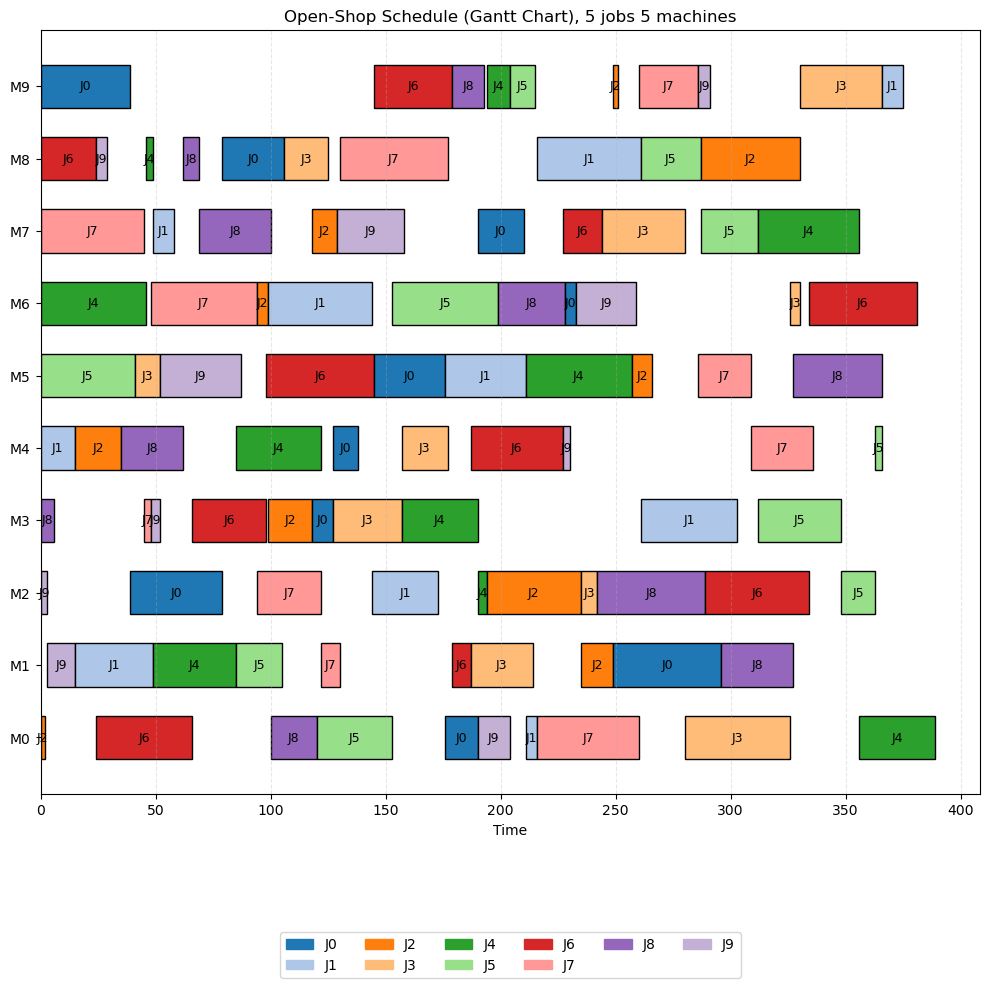

In [98]:
plot_schedule_gantt(best_3['schedule'], makespan=None, title="Open-Shop Schedule (Gantt Chart), 5 jobs 5 machines")

In [99]:
best3_mod = {0: [3, 1, 0, 4, 2], 1: [3, 2, 0, 1, 4], 2: [1, 3, 4, 2, 0], 3: [2, 0, 4, 3, 1], 4: [2, 1, 0, 4, 3]}
best3_mod

{0: [3, 1, 0, 4, 2],
 1: [3, 2, 0, 1, 4],
 2: [1, 3, 4, 2, 0],
 3: [2, 0, 4, 3, 1],
 4: [2, 1, 0, 4, 3]}

In [100]:
best3_mod_sched = simulate_open_shop(best3_mod, durations_3)
best3_mod_sched

({0: [(3, 27, 73), (1, 73, 78), (0, 111, 125), (4, 184, 217), (2, 217, 219)],
  1: [(3, 0, 27), (2, 39, 53), (0, 53, 100), (1, 100, 134), (4, 148, 184)],
  2: [(1, 0, 29), (3, 73, 80), (4, 80, 84), (2, 84, 125), (0, 125, 165)],
  3: [(2, 0, 19), (0, 19, 28), (4, 28, 61), (3, 80, 110), (1, 134, 176)],
  4: [(2, 19, 39), (1, 39, 54), (0, 100, 111), (4, 111, 148), (3, 148, 168)]},
 219)

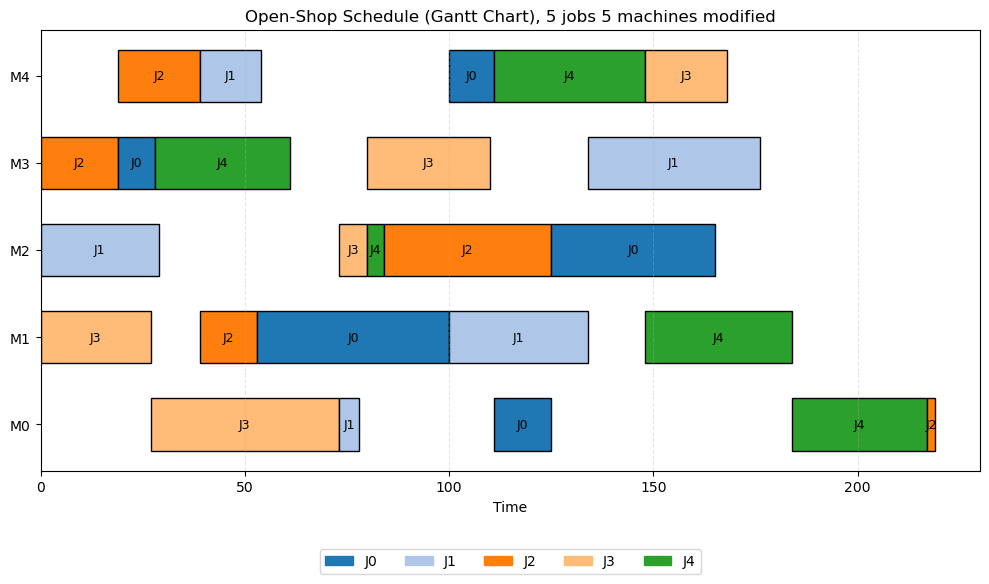

In [101]:
plot_schedule_gantt(best3_mod_sched[0], makespan=None, title="Open-Shop Schedule (Gantt Chart), 5 jobs 5 machines modified")

In [102]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_best_makespan_per_gen(master_df, title="Best Makespan per Generation"):
    best_by_gen = (master_df
                   .groupby("Gen", as_index=False)["Makespan"]
                   .min()
                   .sort_values("Gen"))

    plt.figure(figsize=(8,4))
    plt.plot(best_by_gen["Gen"], best_by_gen["Makespan"], marker="o")
    plt.xlabel("Generation")
    plt.ylabel("Best Makespan")
    plt.title(title)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()
    return best_by_gen


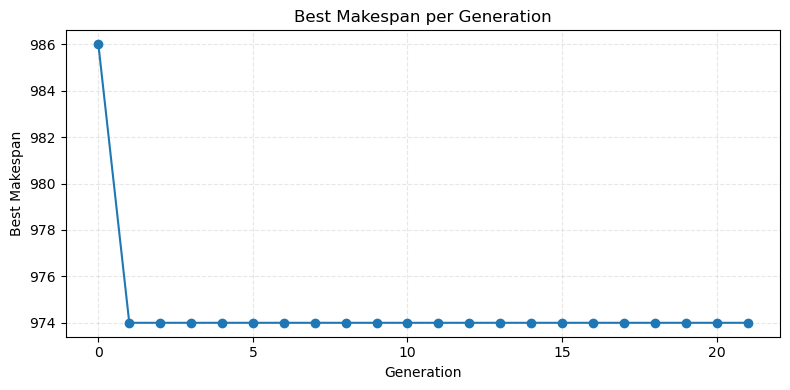

,Gen,Makespan
0,0,986
1,1,974
2,2,974
3,3,974
4,4,974
5,5,974
6,6,974
7,7,974
8,8,974
9,9,974


In [103]:
plot_best_makespan_per_gen(master_df_1, title="Best Makespan per Generation")


In [140]:
import pandas as pd

# Average makespans (fill in from your results)
GA = [1128.2, 263.8, 384.2, 4861.2, 2456.6, 1695.2, 2601.67, 4792.4, 9175.33, 7263.67]
RS = [1135.4, 263.6, 395.4, 4989.8, 2493.4, 1719.2, 2629, 4803.5, 9256.67, 7294]

tests = list(range(1, 11))

# Compute relative differences
abs_diff = [rs - ga for ga, rs in zip(GA, RS)]
pct_improve = [((rs - ga) / rs) * 100 for ga, rs in zip(GA, RS)]

# Build summary DataFrame
df_rel = pd.DataFrame({
    "Test": tests,
    "GA_WoC_Avg": GA,
    "Random_Avg": RS,
    "Abs_Difference": abs_diff,
    "Percent_Improvement (%)": pct_improve
})

print(df_rel.to_string(index=False))


 Test  GA_WoC_Avg  Random_Avg  Abs_Difference  Percent_Improvement (%)
    1     1128.20     1135.40            7.20                 0.634138
    2      263.80      263.60           -0.20                -0.075873
    3      384.20      395.40           11.20                 2.832575
    4     4861.20     4989.80          128.60                 2.577258
    5     2456.60     2493.40           36.80                 1.475896
    6     1695.20     1719.20           24.00                 1.395998
    7     2601.67     2629.00           27.33                 1.039559
    8     4792.40     4803.50           11.10                 0.231082
    9     9175.33     9256.67           81.34                 0.878718
   10     7263.67     7294.00           30.33                 0.415821


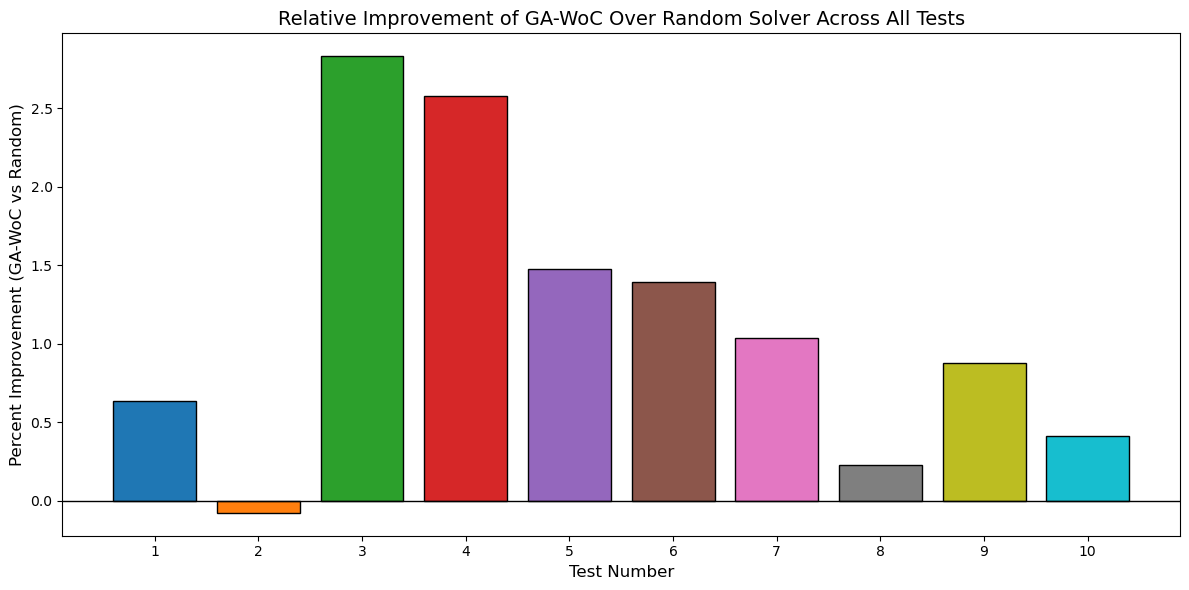

In [141]:
import matplotlib.pyplot as plt
import numpy as np

# Average makespans per test (GA-WoC and Random Solver)
GA = [1128.2, 263.8, 384.2, 4861.2, 2456.6, 1695.2, 2601.67, 4792.4, 9175.33, 7263.67]
RS = [1135.4, 263.6, 395.4, 4989.8, 2493.4, 1719.2, 2629, 4803.5, 9256.67, 7294]

tests = np.arange(1, 11)

# Percent improvement: positive means GA-WoC is better
pct_improve = [((rs - ga) / rs) * 100 for ga, rs in zip(GA, RS)]

# Color map for distinct colors
colors = plt.cm.tab10(np.linspace(0, 1, 10))

plt.figure(figsize=(12, 6))
plt.bar(tests, pct_improve, color=colors, edgecolor='black')

# Labels and title
plt.xlabel("Test Number", fontsize=12)
plt.ylabel("Percent Improvement (GA-WoC vs Random)", fontsize=12)
plt.title("Relative Improvement of GA-WoC Over Random Solver Across All Tests", fontsize=14)

# Horizontal line at 0%
plt.axhline(0, color='black', linewidth=1)

# Display all test numbers on x-axis
plt.xticks(tests)

plt.tight_layout()
plt.show()


In [143]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def plot_woc_operator_boxplot(master_df):
    """
    Creates a boxplot + stripplot comparing the makespan distributions
    of the three WoC operators: woc_adj, woc_seq, and woc_ops.
    """

    ops = ["woc_adj", "woc_seq", "woc_ops"]

    # Filter to only WoC operator rows
    df = master_df[master_df["Source"].isin(ops)].copy()

    plt.figure(figsize=(10, 6))

    # Boxplot
    sns.boxplot(
        data=df,
        x="Source",
        y="Makespan",
        palette="Set2"
    )

    # Overlay stripplot
    sns.stripplot(
        data=df,
        x="Source",
        y="Makespan",
        color="black",
        size=3,
        alpha=0.4
    )

    plt.title("Performance of WoC Operators (Makespan Distribution)")
    plt.xlabel("WoC Operator")
    plt.ylabel("Makespan")
    plt.tight_layout()
    plt.show()


C:\Users\mjpon\AppData\Local\Temp\ipykernel_34532\1647053989.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


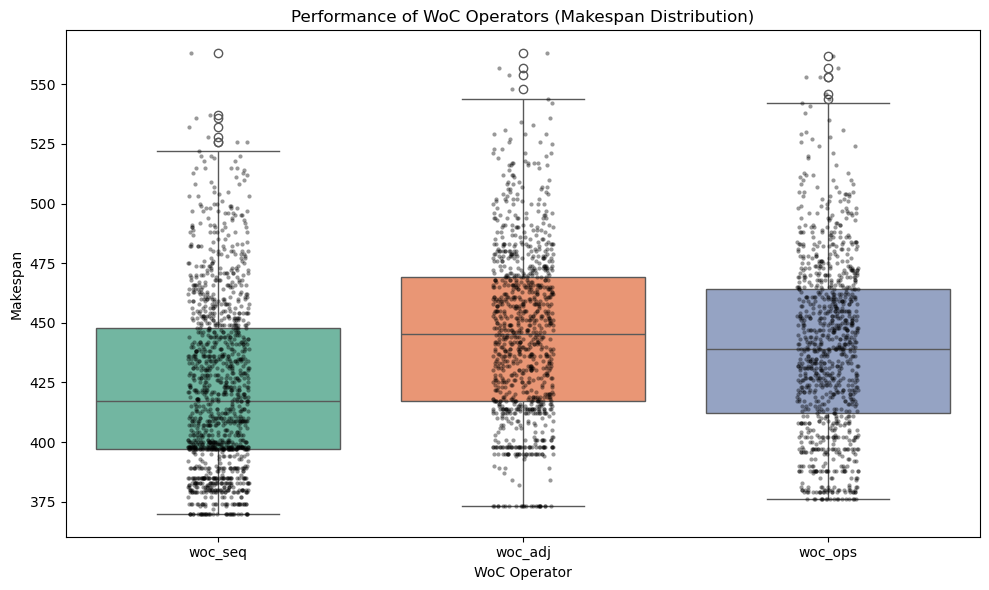

In [144]:
plot_woc_operator_boxplot(master_df_3)

In [167]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_woc_operator_gen_progress(master_df):
    """
    Plots average makespan per generation for each WoC operator.
    Expected columns: Gen, Source, Makespan.
    """

    ops = ["woc_adj", "woc_seq", "woc_ops"]

    # Filter relevant rows
    df = master_df[master_df["Source"].isin(ops)].copy()

    # Ensure makespan numeric
    df["Makespan"] = pd.to_numeric(df["Makespan"], errors="coerce")
    df = df.dropna(subset=["Makespan"])

    # Compute avg makespan per (operator, gen)
    avg_by_gen = (
        df.groupby(["Source", "Gen"], as_index=False)["Makespan"]
        .mean()
        .sort_values(["Source", "Gen"])
    )

    # Plot
    plt.figure(figsize=(12, 6))

    for op in ops:
        sub = avg_by_gen[avg_by_gen["Source"] == op]
        plt.plot(
            sub["Gen"],
            sub["Makespan"],
            marker="o",
            linewidth=2,
            label=op
        )

    plt.title("Average Makespan per Generation for WoC Operators (Test 4: 15 Jobs, 10 Machines)")
    plt.xlabel("Generation")
    plt.ylabel("Average Makespan")
    plt.legend(title="Operator")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


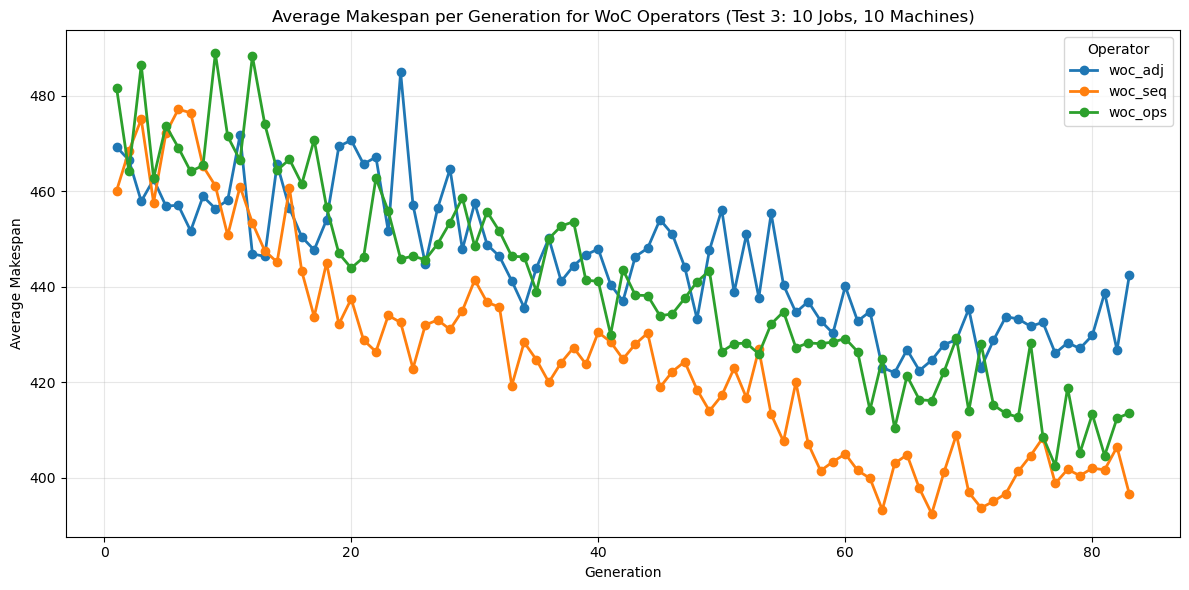

In [154]:
plot_woc_operator_gen_progress(master_df_3)


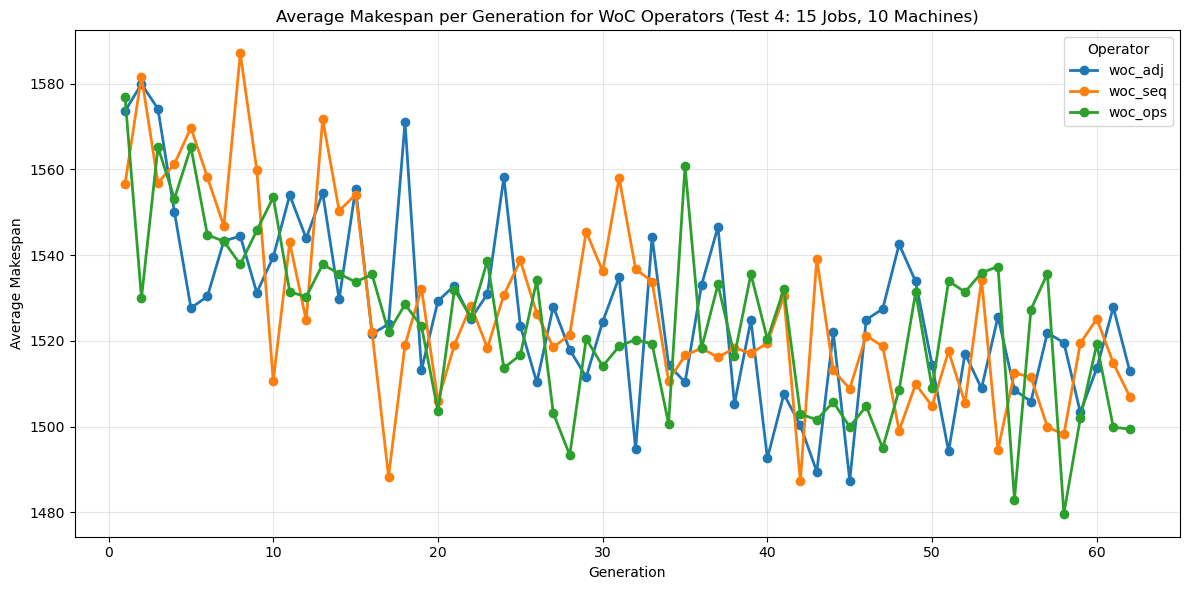

In [168]:
plot_woc_operator_gen_progress(master_df_4)